<a id="TMP_1ce5"></a>

# <span style="color:rgb(213,80,0)">Create all the figures</span>
<!-- Begin Toc -->

## Table of Contents
&#8195;[Input data loading](#TMP_0d97)

&#8195;[Figure 2: Boxplot and violin plot](#TMP_8c1d)

&#8195;[Configuration loading](#TMP_8d7f)

&#8195;[Loop thought the configurations](#TMP_1c22)

&#8195;[Figure 3: t stat and min max estimated age](#TMP_390f)

&#8195;[Figure 4: Results from analysis of 165,888 permutations, ordered by the values of t1](#TMP_0441)

&#8195;[Figure 5: Results from analysis of 165,888 permutations: histogram of values of R2](#TMP_9d57)

&#8195;[Find the set of most plausible configurations](#TMP_1bf8)

&#8195;[Distance from the centroid](#TMP_9c7a)

&#8195;[Figure 6: t stat and min max estimated age with magenta lines for the 564 configurations](#TMP_45a2)

&#8195;[Figure 7: Best configuration 1\-2](#TMP_7f48)

&#8195;[Figure 8: Best configuration 3\-6](#TMP_46f2)

&#8195;[Figure 9: Weighted regression: outlier detection on the most plausible configuration](#TMP_2584)

&#8195;[Figure 10: HistFS plots](#TMP_1694)

&#8195;[Section 10: find minimum and maximum dbp](#TMP_175e)

&#8195;[Section 10: number of t tests greater than 1.96 for horizontal and vertical](#TMP_3284)

<!-- End Toc -->

<a id="TMP_0d97"></a>

## Input data loading

In [1]:
close all;
% Remove all variables from workspace
clear;


filename='layout2024.xlsx';


YY=readtable(filename,'ReadRowNames',false,'Range','F2:G18');
y=YY{:,1};
se=YY{:,2};


<a id="TMP_8c1d"></a>

## Figure 2: Boxplot and violin plot


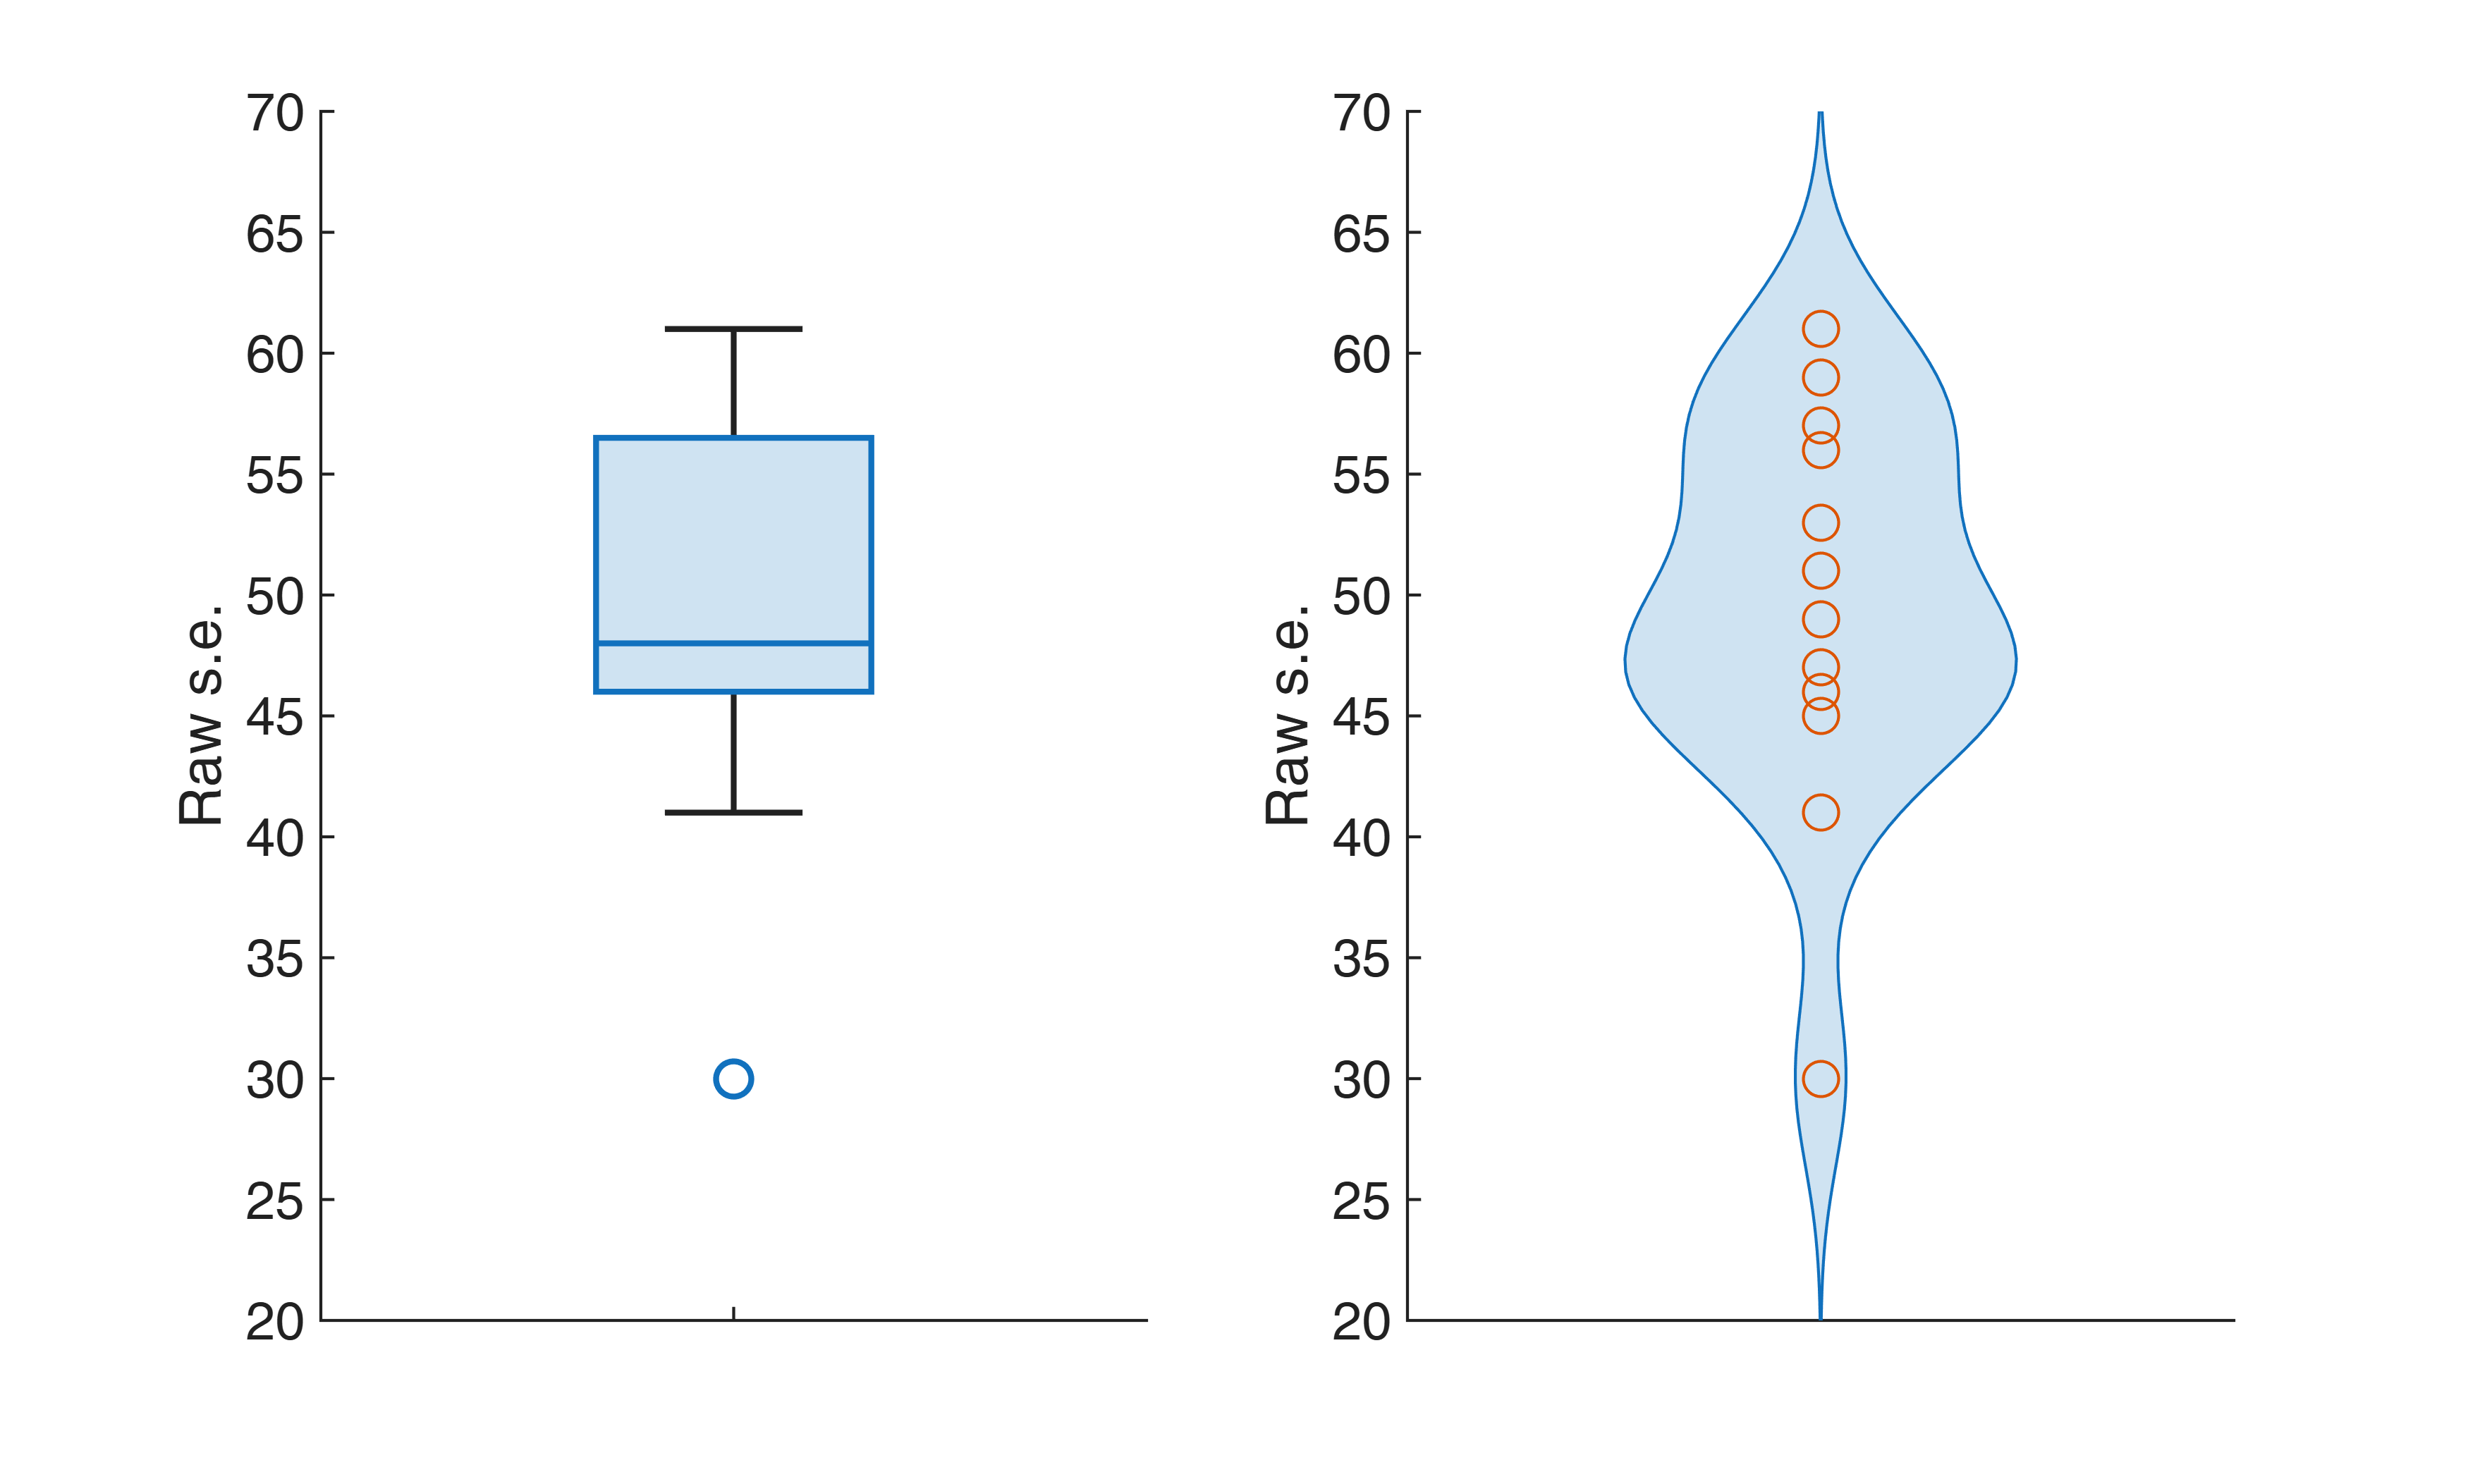

In [2]:
figure('Name', 'Figure 2: Boxplot and violin plot of raw standard errors.', 'NumberTitle', 'off');
yl=[20 70];
subplot(1,2,1)
boxchart(se)
ylim(yl)
ylabel('Raw s.e.')
set(gca,"XTickLabel","")
subplot(1,2,2)
violinplot(se)
hold on
scatter(ones(length(y),1),se)
ylim(yl)
set(gca,"XTickLabel","")
ylabel('Raw s.e.')

In [3]:
prin=0;
if prin==1
    print -depsc figures/se.eps
end


<a id="TMP_8d7f"></a>

## Configuration loading

In [4]:
zone='k2:l13';
% Load the  plausible set of configurations for Arizona
AR=readmatrix(filename,"Range",zone);


per=perms(1:4);
perAR=[per;per+4;per+8];
lab={'A1' 'A2' 'A3'};
len=size(per,1);
ARlab=reshape(repmat(lab,len,1),size(perAR,1),1);


% Load the 4 plausible set of configurations for Oxford
zone='n2:o13';
OX=readmatrix(filename,"Range",zone);
per=perms(1:3);
perOX=[per;per+3;per+6;per+9];
lab={'O1' 'O2' 'O3' 'O4'};
len=size(per,1);
OXlab=reshape(repmat(lab,len,1),size(perOX,1),1);


% Load the 4 plausible set of configurations for Zurich1
zone='q2:r13';
ZU1=readmatrix(filename,"Range",zone);
per=perms(1:3);
perZU1=[per;per+3;per+6;per+9];
lab={'Z1' 'Z2' 'Z3' 'Z4'};
len=size(per,1);
ZU1lab=reshape(repmat(lab,len,1),size(perZU1,1),1);


% Load the 2 plausible set of configurations for Zurich2
zone='t2:u5';
ZU2=readmatrix(filename,"Range",zone);
per=perms(1:2);
perZU2=[per;per+2];
lab={'Z5' 'Z6'};
len=size(per,1);
ZU2lab=reshape(repmat(lab,len,1),size(perZU2,1),1);


sAR=size(perAR,1);
sOX=size(perOX,1);
sZU1=size(perZU1,1);
sZU2=size(perZU2,1);


nsamp=sAR*sOX*sZU1*sZU2;


lab=cell(nsamp,1);


% Matrix TTpval will contain the p-value of the tests for horizontal and
% vertical spatial effect
TTpval=NaN(nsamp,2);


FitMinMax=zeros(nsamp,2);


nR2=sAR*sOX*sZU1*sZU2;


<a id="TMP_1c22"></a>

## Loop thought the configurations

In [5]:
% Initialize matrix which will contain distribution of R2 for real data
R2real=NaN(nsamp,2);
% Initialize matrix which will contain distribution of p-values
% for t tests of spatial effects
TTpvalreal=R2real;
TTstatreal=R2real;


% Arizona values go in pairs
y(1:8)=[y(1:2:7);y(2:2:8)];
se(1:8)=[se(1:2:7);se(2:2:8)];


labRows=[repelem("AR",8,1); repelem("OX",3,1); repelem("ZU",5,1)];


Xall=zeros(length(y),2,nsamp);


ijk=0;
% Loop through all possible configurations keeping y fixed
for i=1:sAR % loop for  ARIZONA
    for j=1:sOX % loop for OXFORD
        for k=1:sZU1 % loop for ZURICH1
            for l=1:sZU2 % loop for ZURICH2
                    X=[repmat(AR(perAR(i,:),:),2,1);OX(perOX(j,:),:);ZU1(perZU1(k,:),:);ZU2(perZU2(l,:),:)];
                    stat = regstats(y,X,'linear',{'rsquare' 'tstat' 'fstat' 'yhat'});
                % disp([i j k]);
                ijk=ijk+1;


                lab(ijk)=cellstr(['A' num2str(i) 'O' num2str(j) 'Z' num2str(k) 'Z' num2str(l) ]);


                % Store the configuration
                Xall(:,:,ijk)=X;


                % Store p values of tstat
                TTpvalreal(ijk,:)=stat.tstat.pval(2:3);
                % Store values of t-statistics
                TTstatreal(ijk,:)=stat.tstat.t(2:3);


                FitMinMax(ijk,:)=[min(stat.yhat) max(stat.yhat)];


                % Store p-value of F test
                R2real(ijk,1)=stat.fstat.pval;


                % Store R square value in the second column
                R2real(ijk,2)=stat.rsquare;


            end


        end
    end
end


<a id="TMP_390f"></a>

## Figure 3: t stat and min max estimated age


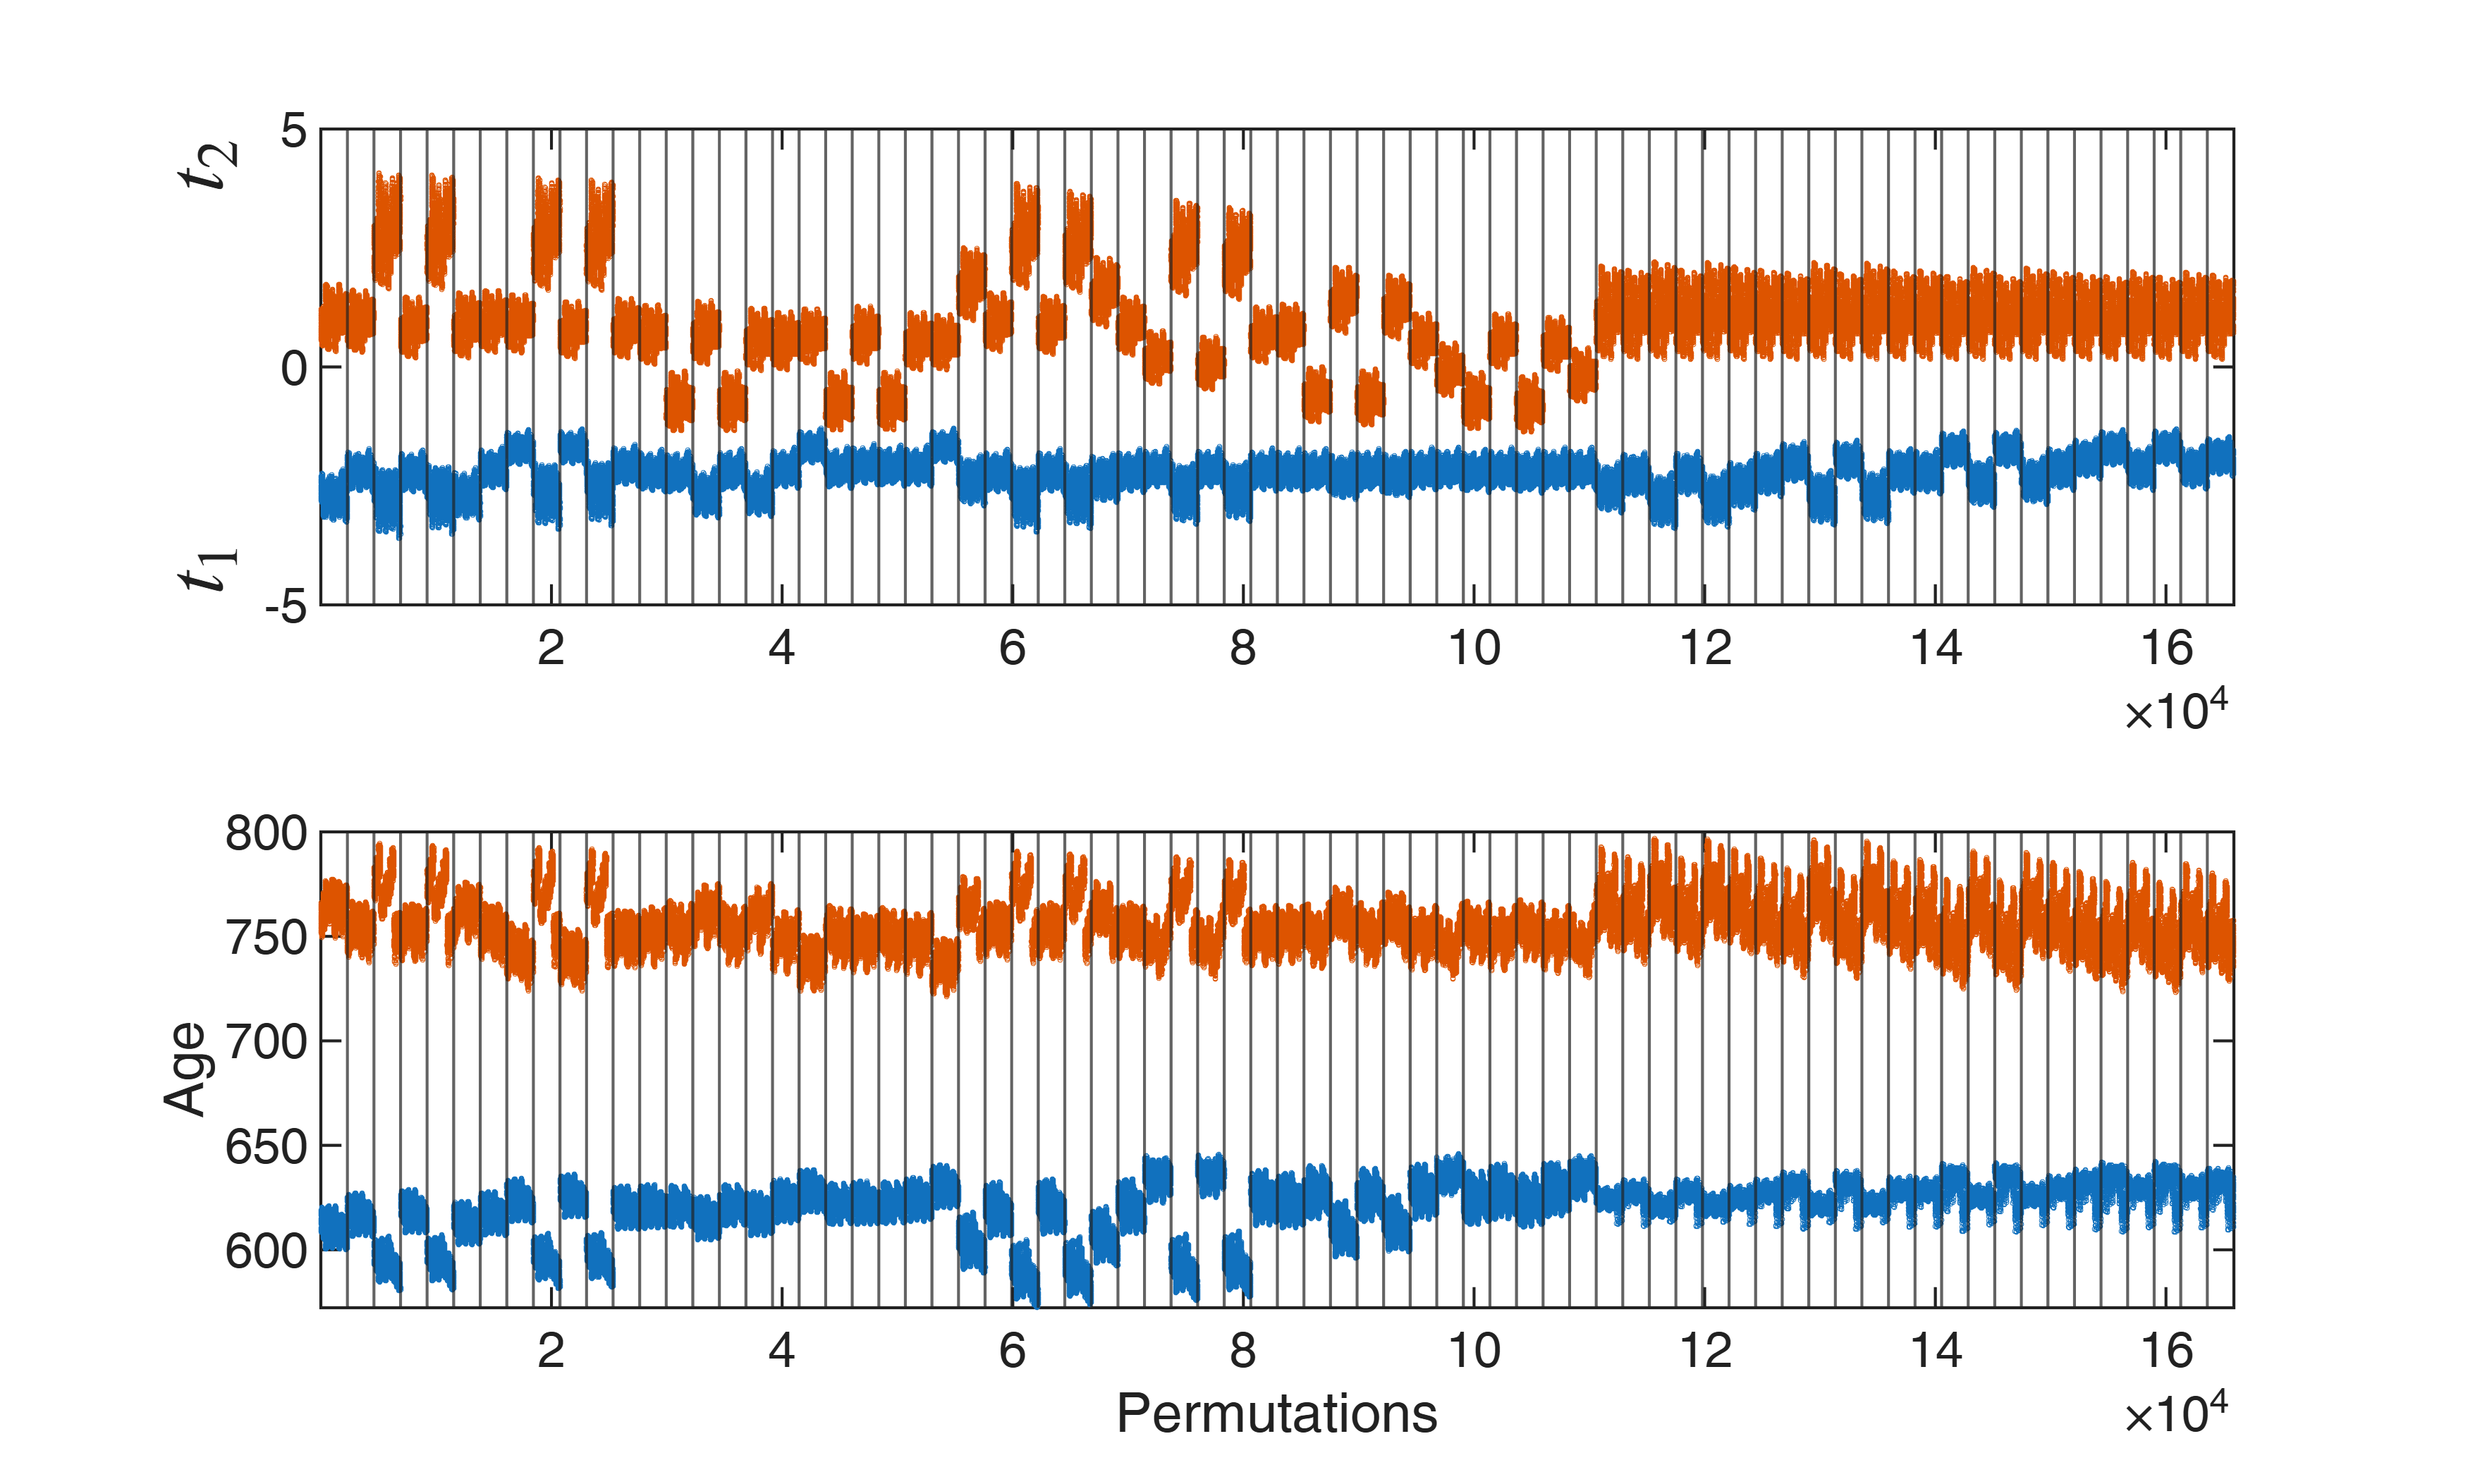

In [6]:
figure('Name', 'Figure 3: t stat and min max estimated age', 'NumberTitle', 'off');
subplot(2,1,1)
plot(TTstatreal,'o','LineWidth',0.01,'MarkerSize',0.8)
ylabel("$t_1$ \qquad \qquad $t_2$",'Interpreter','latex','FontSize',14)
% title('t statistics')
xline(2304:2304:2304*72)
xlim([1 nsamp])
subplot(2,1,2)
plot(FitMinMax,'o','LineWidth',0.01,'MarkerSize',0.8)
% title('Min and max estimated age')
xline(2304:2304:2304*72)
ylabel("Age")
xlabel("Permutations")
xlim([1 nsamp])

In [7]:
prin=0;
if prin==1
    print -depsc tstat.eps
end


<a id="TMP_0441"></a>

## Figure 4: Results from analysis of 165,888 permutations, ordered by the values of t1


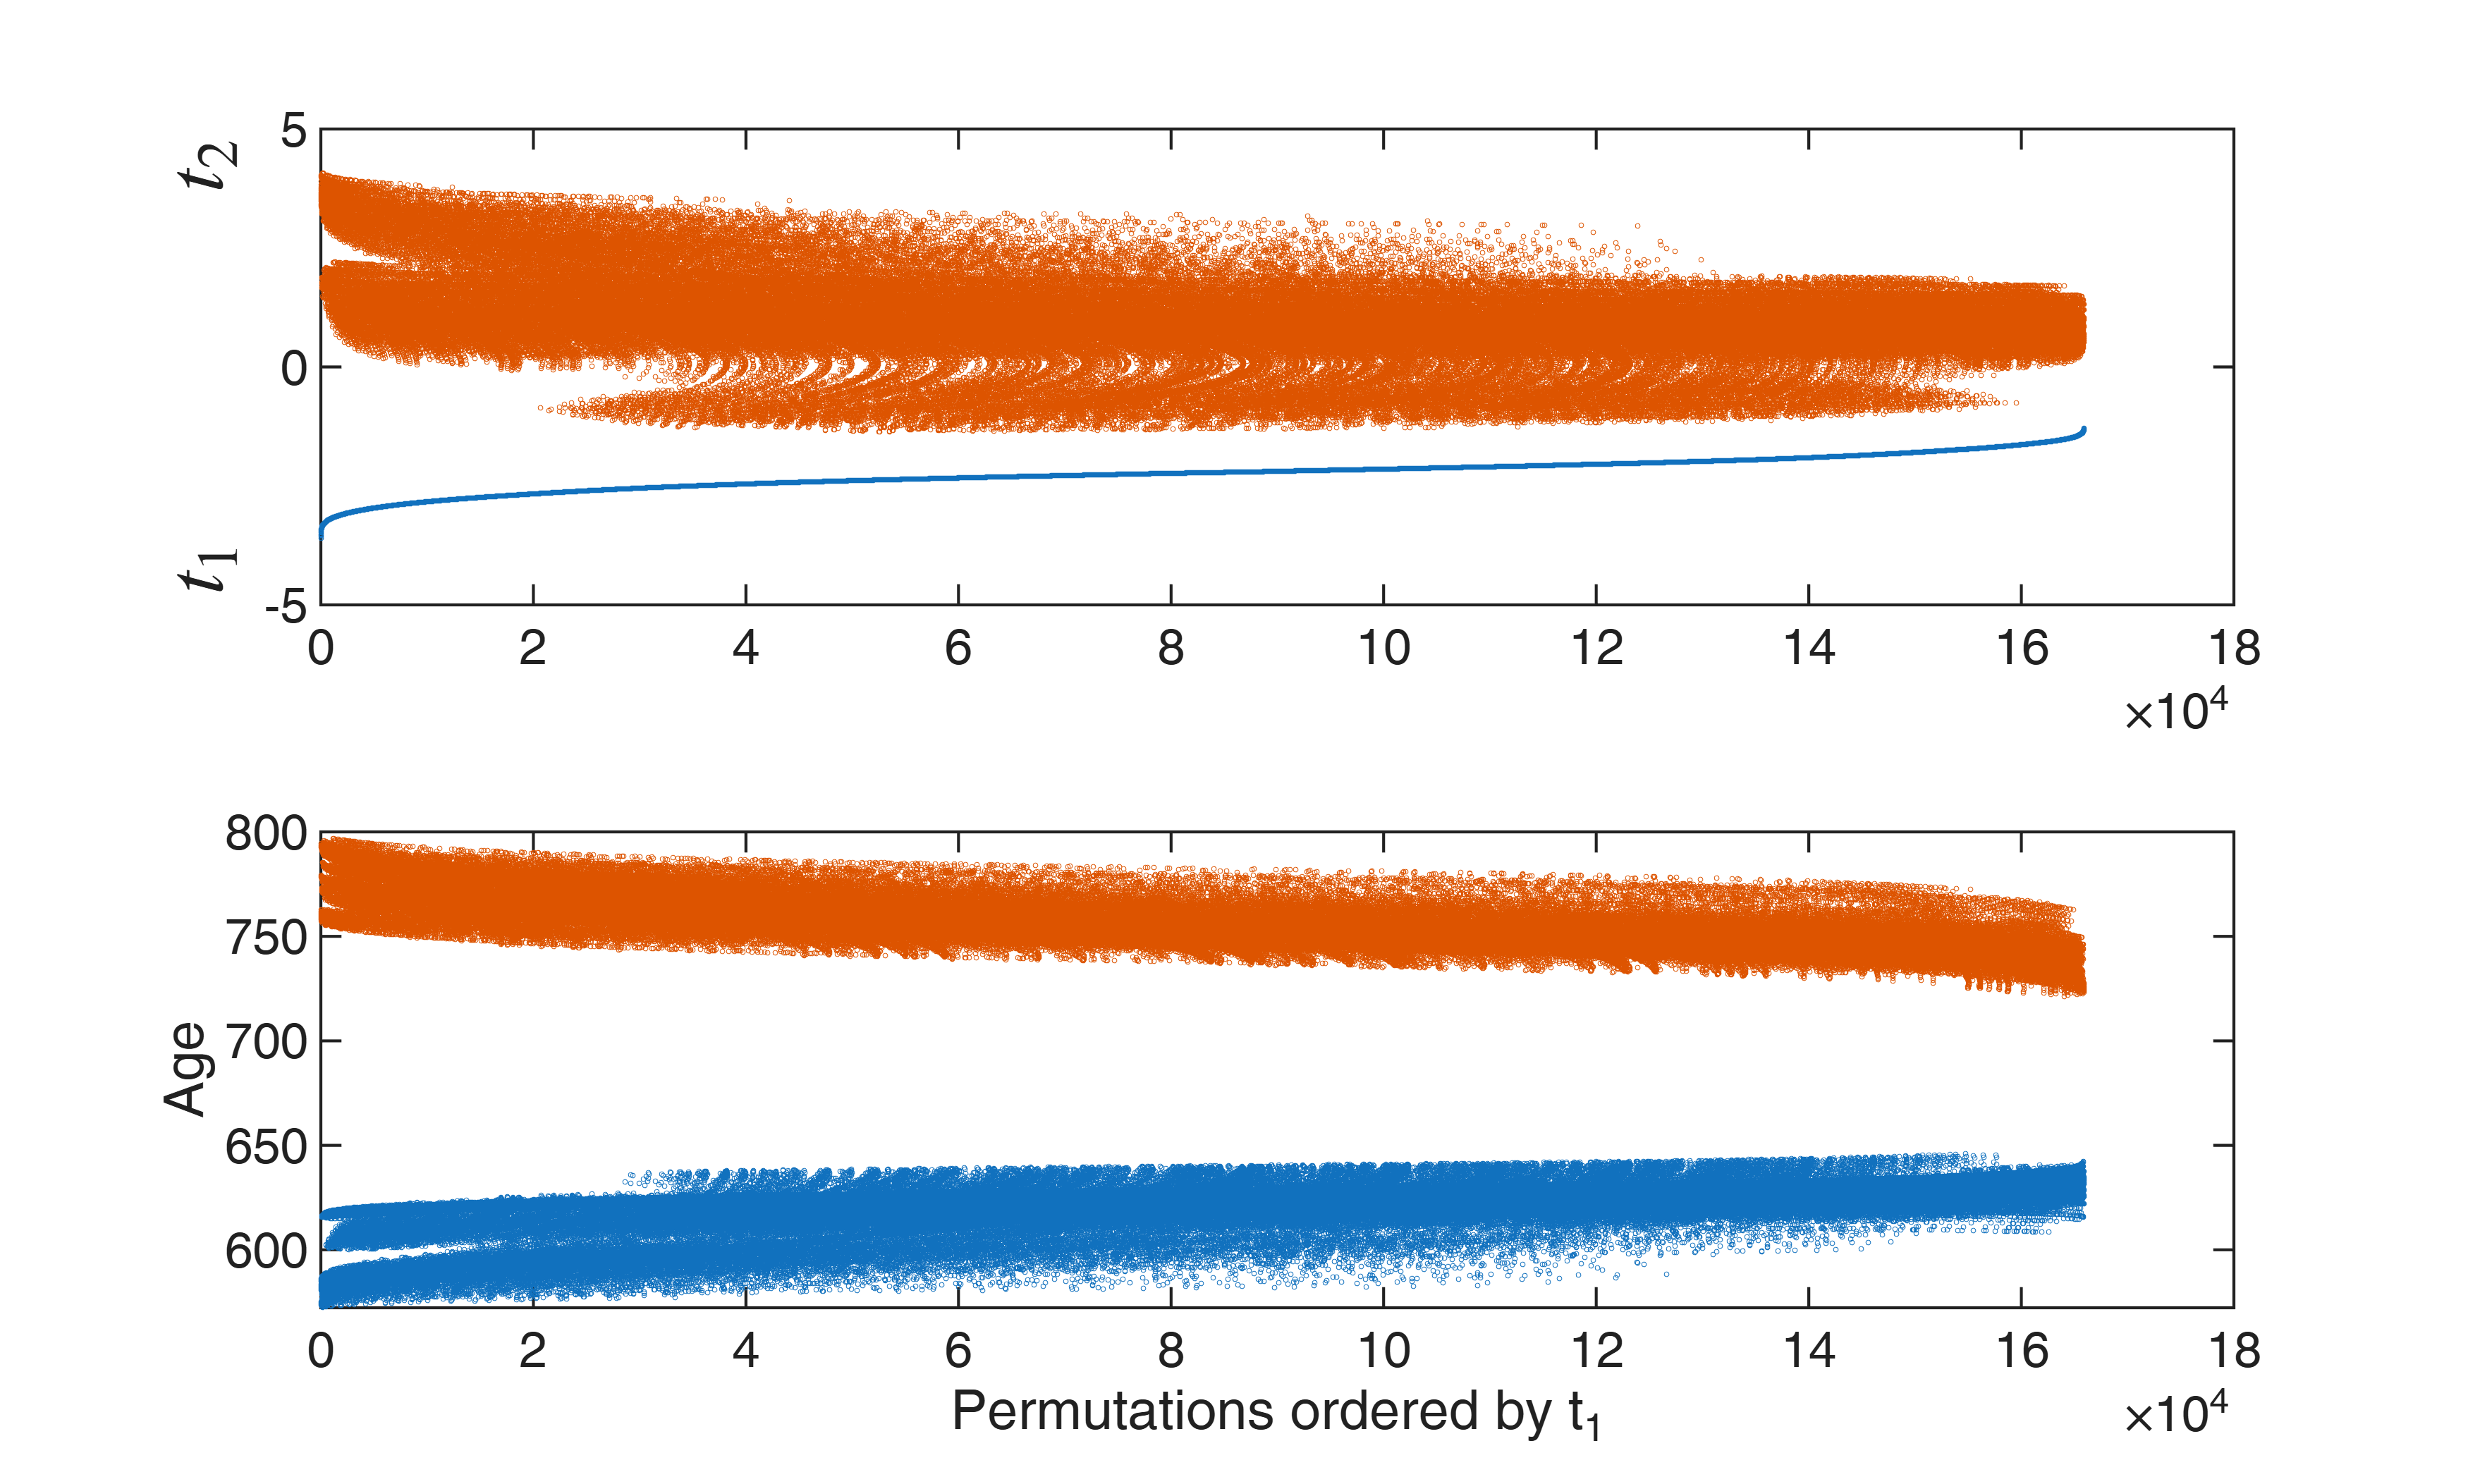

In [8]:
[~,ind]=sort(TTstatreal(:,1),'ascend');


figure('Name', 'Figure 4: t stat using ordered t1', 'NumberTitle', 'off');
subplot(2,1,1)
plot(TTstatreal(ind,:),'o','LineWidth',0.01,'MarkerSize',0.8)
ylabel("$t_1$ \qquad \qquad $t_2$",'Interpreter','latex','FontSize',14)


%title('t statistics')
subplot(2,1,2)
plot(FitMinMax(ind,:),'o','LineWidth',0.01,'MarkerSize',0.8)
xlabel("Permutations ordered by t_1")
ylabel("Age")

In [9]:
% title('Min and max estimated age')
if prin==1
    print -depsc tstatord.eps
end


<a id="TMP_9d57"></a>

## Figure 5: Results from analysis of 165,888 permutations: histogram of values of R2


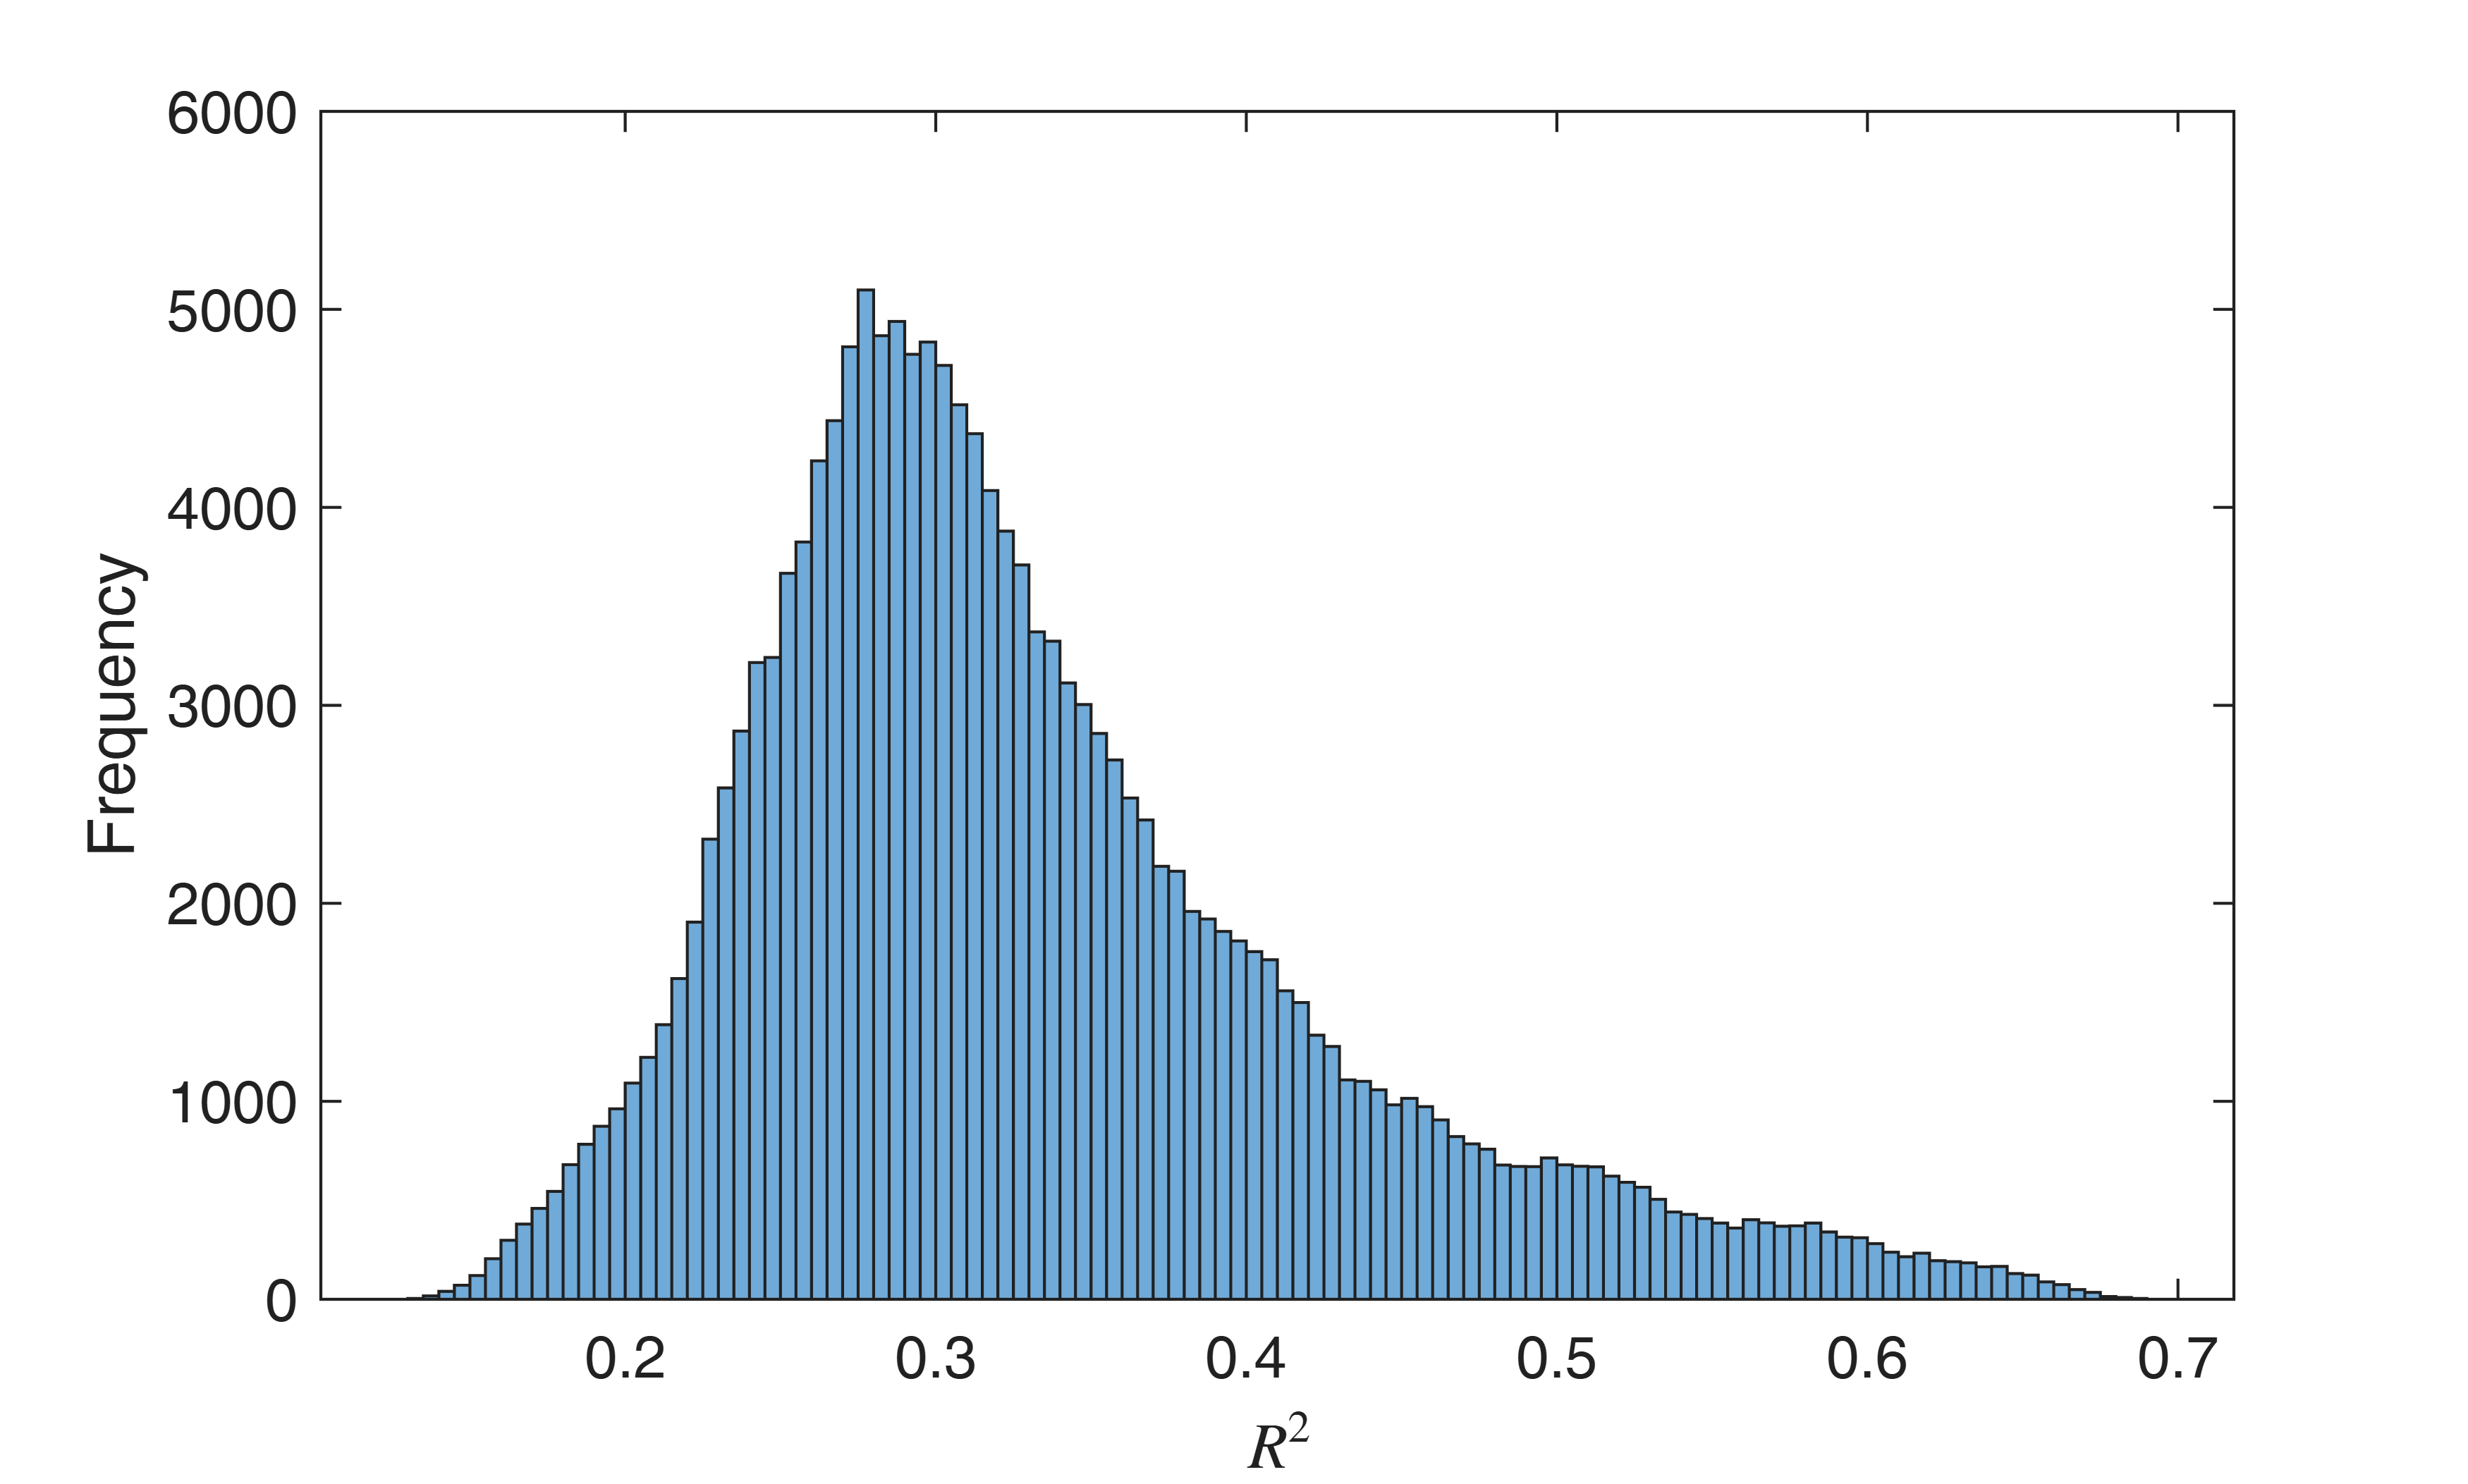

In [10]:
figure('Name', 'Figure 5: histogram of values of R2', 'NumberTitle', 'off');
histogram(R2real(:,2));
xlabel("$R^2$","Interpreter","latex")
ylabel("Frequency")

In [11]:
prin=0;
if prin==1
    print -depsc figures/R2real.eps
end


<a id="TMP_1bf8"></a>

## Find the set of most plausible configurations

In [12]:
quan=quantile(R2real(:,2),0.997);


boo=(R2real(:,2)>quan-0.01 & R2real(:,2)<quan+0.01);
disp('Number of best configurations considered')

Number of best configurations considered

In [13]:
disp(sum(boo))

   564

In [14]:
seq=1:nsamp;
sboo=seq(boo);


group=ones(nsamp,1);
group(boo)=2;


X1=Xall(:,:,sboo);


X2=permute(X1,[3,1,2]);
Xh=X2(:,:,1);
Xv=X2(:,:,2);


<a id="TMP_9c7a"></a>

## Distance from the centroid

In [15]:
Chor=mean(Xh,1);
disHOR=sum((Xh-Chor).^2,2);


Cver=mean(Xv,1);
disVER=sum((Xv-Cver).^2,2);
[dissor,indsor]=sort(disHOR+disVER);


<a id="TMP_45a2"></a>

## Figure 6: t stat and min max estimated age with magenta lines for the 564 configurations


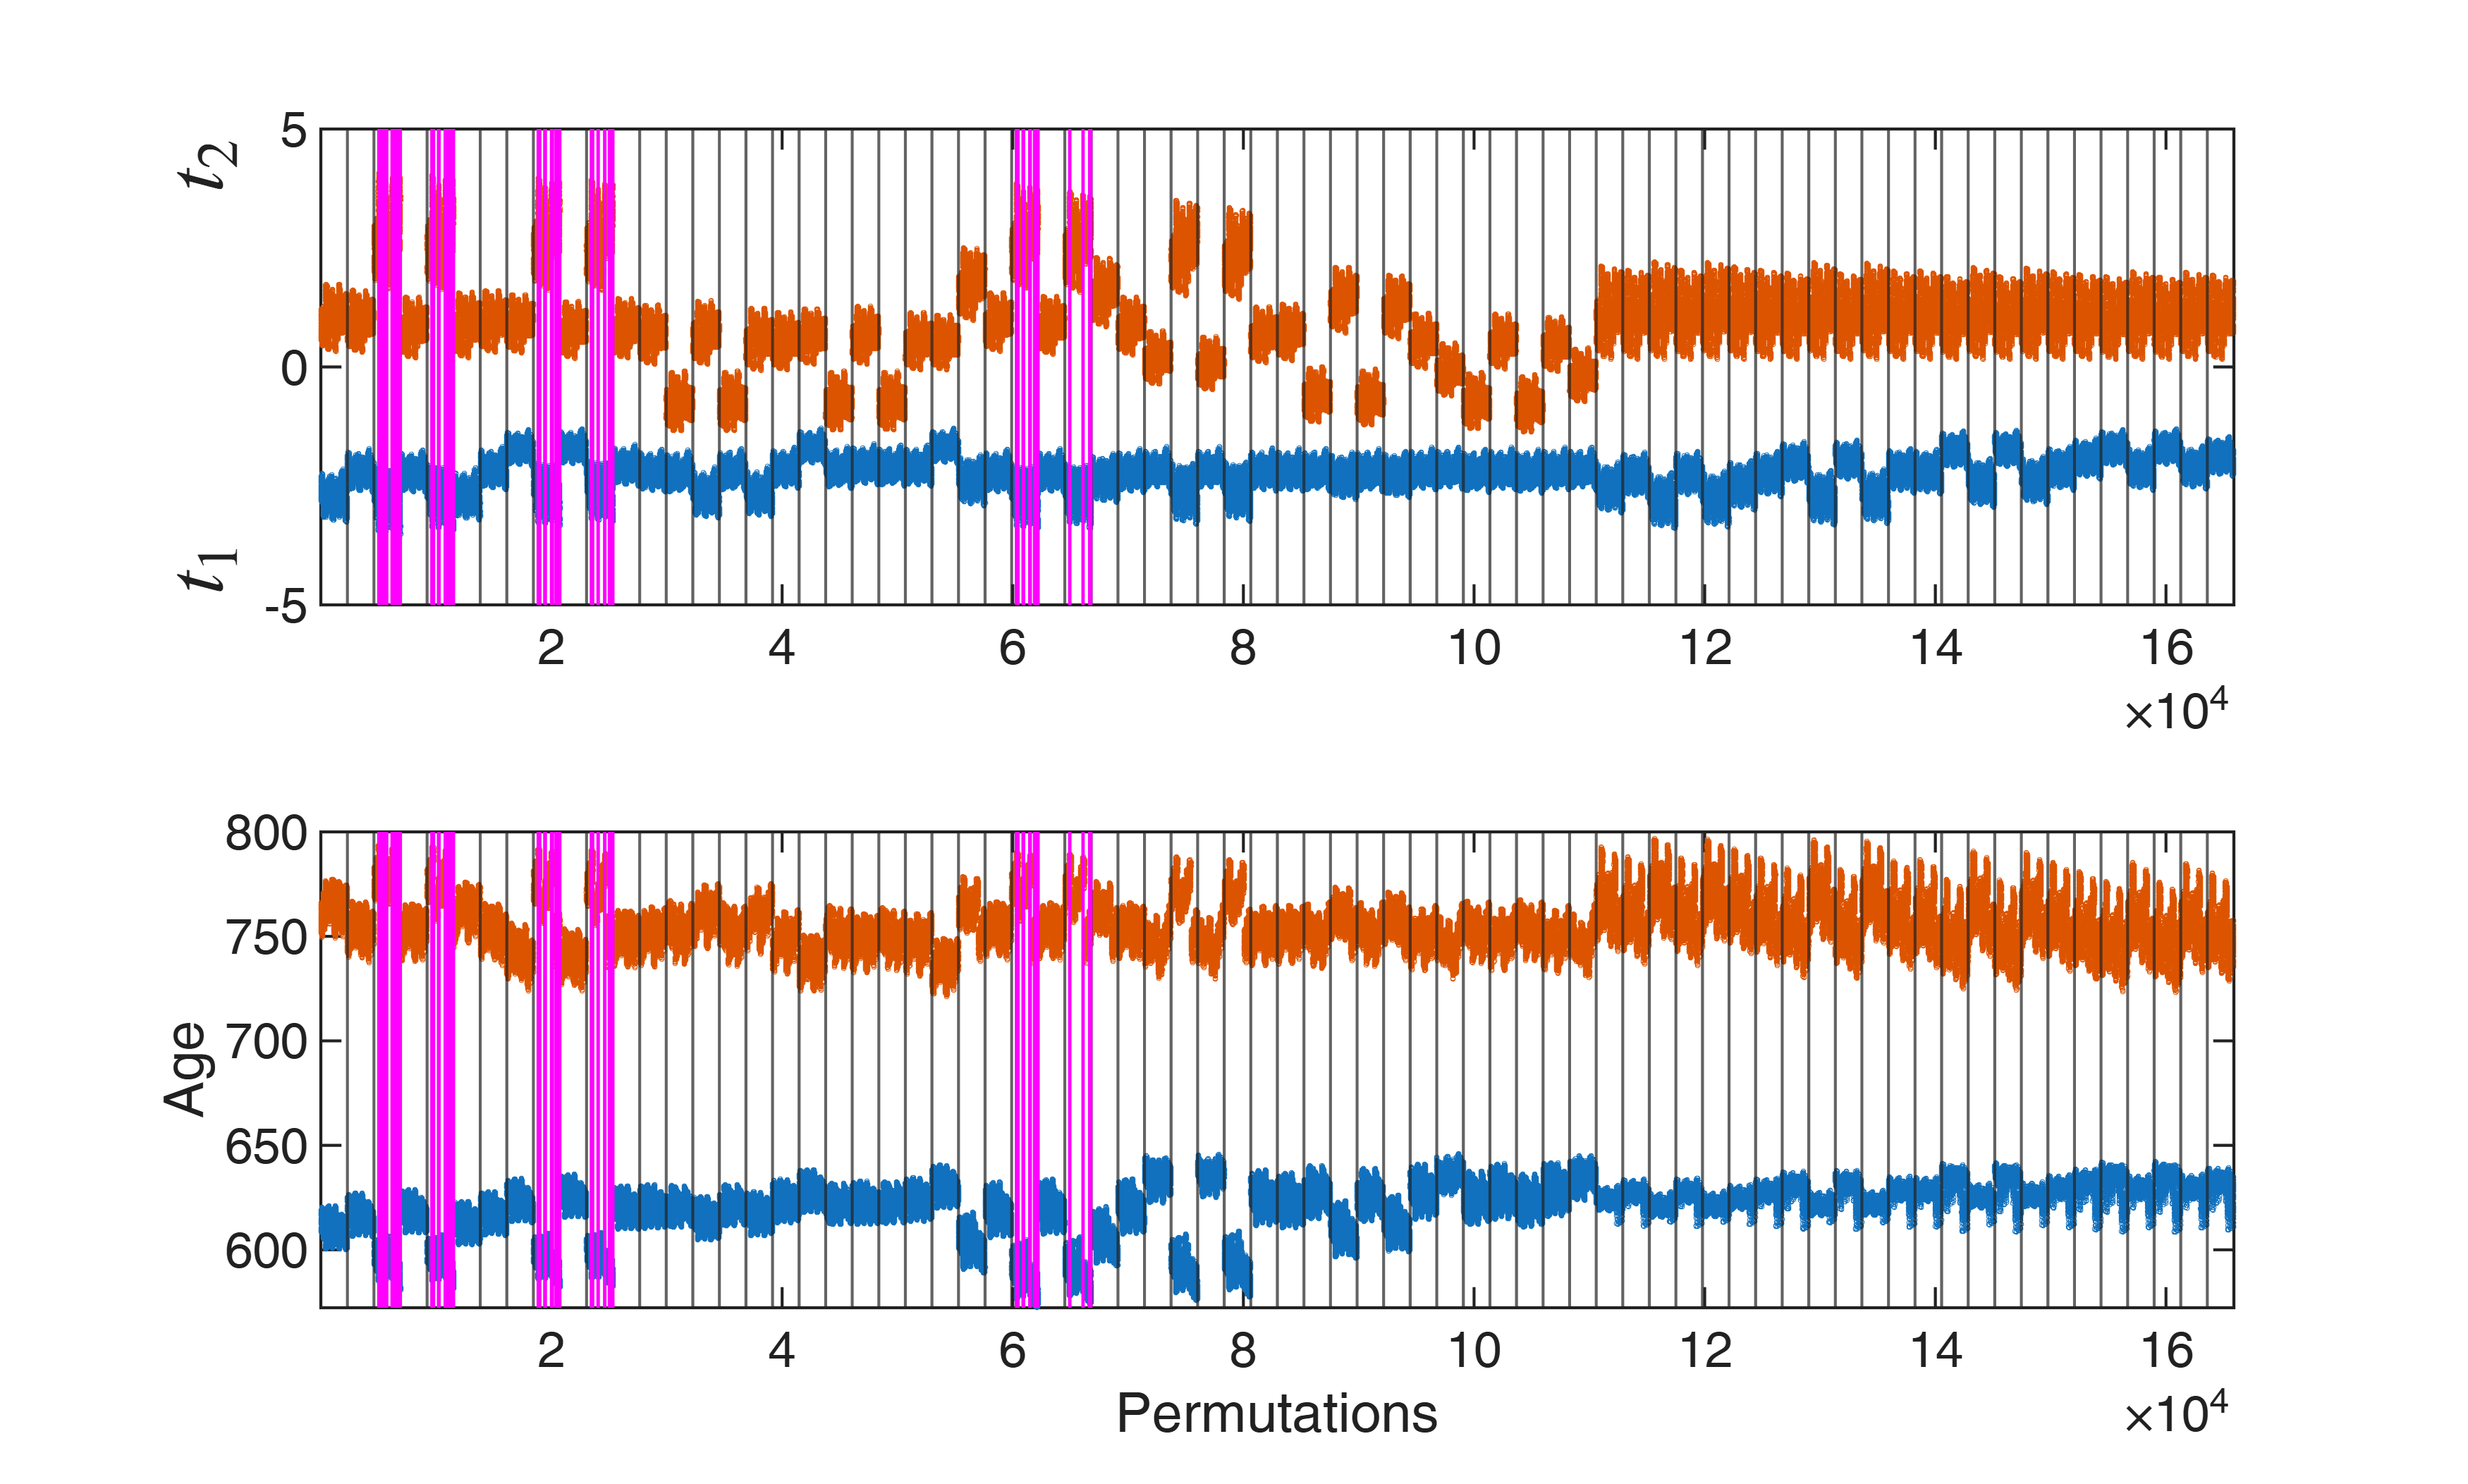

In [16]:
figure('Name', 'Figure 6: t stat and min max estimated age (with magenta lines)', 'NumberTitle', 'off');
% Put withsboo to true or false in order to add the magenta lines
withsboo=true;
subplot(2,1,1)
plot(TTstatreal,'o','LineWidth',0.01,'MarkerSize',0.8)
ylabel("$t_1$ \qquad \qquad $t_2$",'Interpreter','latex','FontSize',14)
% title('t statistics')
xline(2304:2304:2304*72)
if withsboo==true
    xline(sboo,'m')
end
xlim([1 nsamp])
subplot(2,1,2)
plot(FitMinMax,'o','LineWidth',0.01,'MarkerSize',0.8)
% title('Min and max estimated age')
xline(2304:2304:2304*72)
if withsboo==true
    xline(sboo,'m')
end
ylabel("Age")
xlabel("Permutations")
xlim([1 nsamp])

In [17]:
prin=0;
if prin==1
    print -depsc figures/tstatwithbest.eps
end


<a id="TMP_7f48"></a>

## Figure 7: Best configuration 1\-2


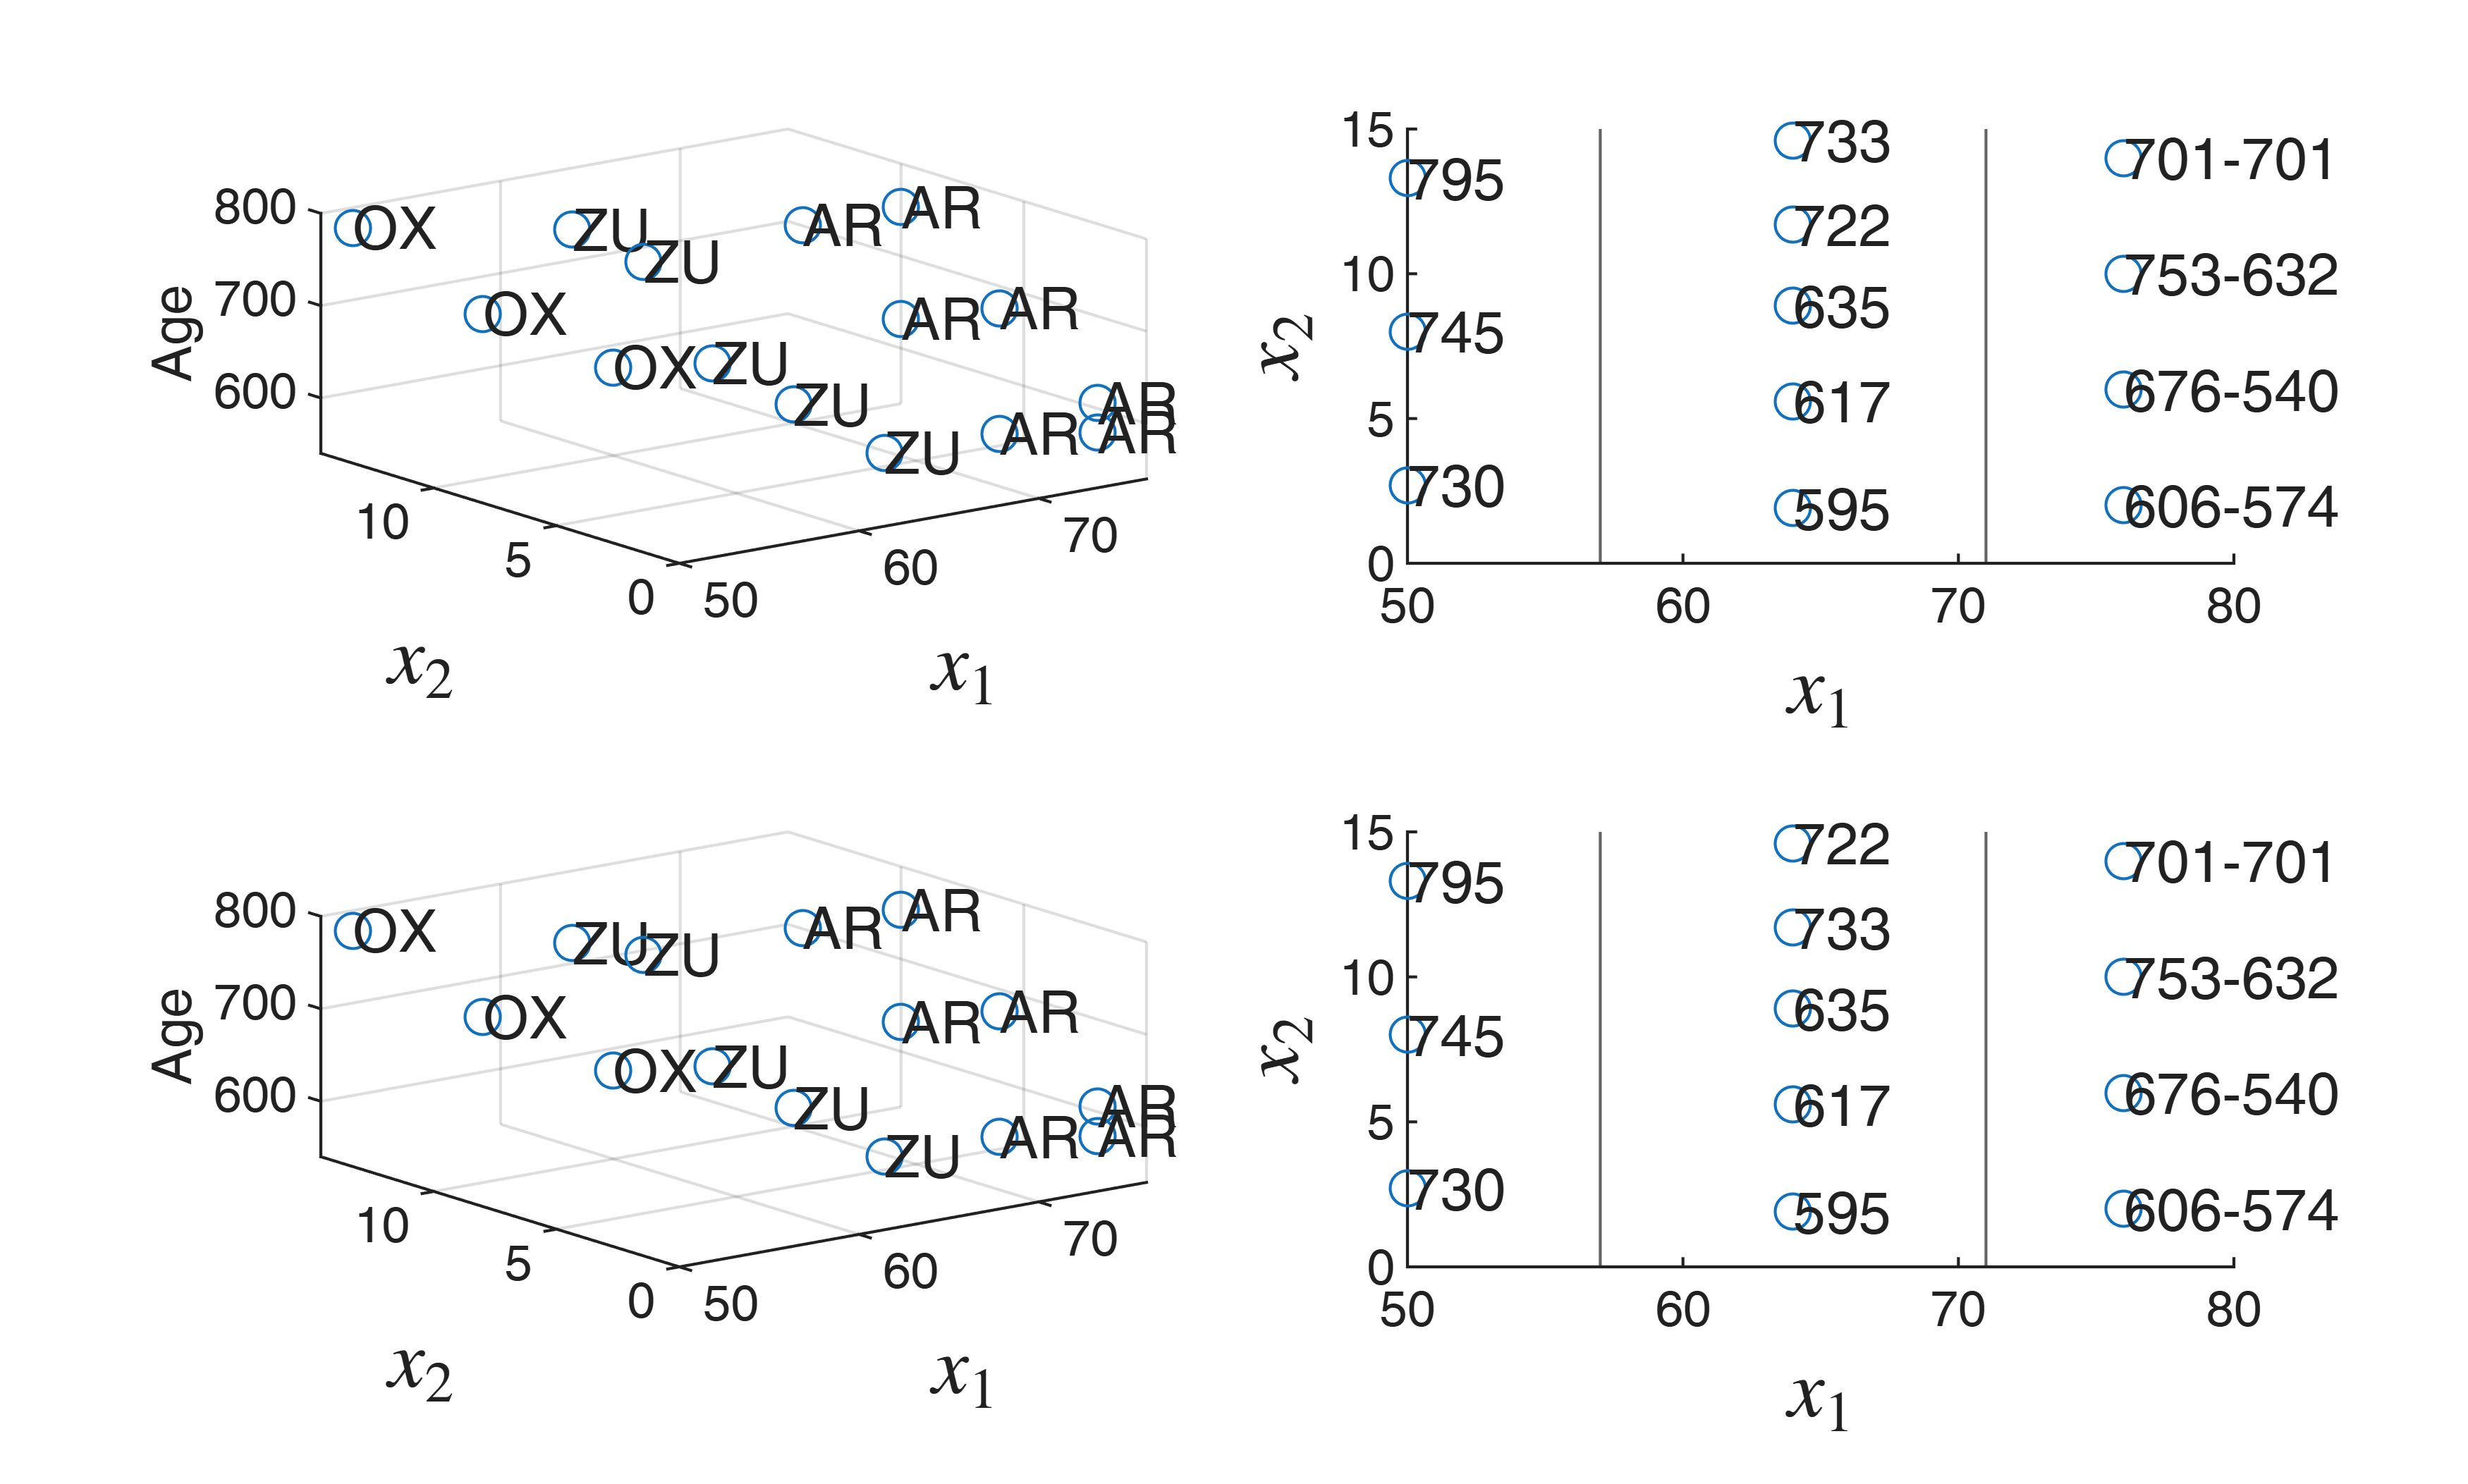

In [18]:
fs=14;
withtitle=false;
figure('Name', 'Figure 7: Best configurations 1-2', 'NumberTitle', 'off');
position=1;
best=indsor(position);
Xbest=X1(:,:,best);
subplot(2,2,1)
scatter3(Xbest(:,1),Xbest(:,2),y)
text(Xbest(:,1),Xbest(:,2),y,labRows)
xlabel('Horizontal coordinate')
ylabel('Vertical coordinate')
xlabel("$x_1$","Interpreter","latex","FontSize",fs)
ylabel("$x_2$","Interpreter","latex","FontSize",fs)


zlabel("Age")
if withtitle==true
    title(['Configuration in position ' num2str(position)])
end
labXbest=[string(y(1:4))+"-"+string(y(5:8)); string(y(9:end))];
Xbestc=Xbest([1:4 9:end],:);
subplot(2,2,2)
scatter(Xbestc(:,1),Xbestc(:,2),'o')
text(Xbestc(:,1),Xbestc(:,2),labXbest);
xlabel("$x_1$","Interpreter","latex","FontSize",fs)
ylabel("$x_2$","Interpreter","latex","FontSize",fs)
xline([57 71])
if withtitle==true
    title(['Configuration in position ' num2str(position)])
end
position=2;
best=indsor(position);
Xbest=X1(:,:,best);
subplot(2,2,3)
scatter3(Xbest(:,1),Xbest(:,2),y)
text(Xbest(:,1),Xbest(:,2),y,labRows)
xlabel("$x_1$","Interpreter","latex","FontSize",fs)
ylabel("$x_2$","Interpreter","latex","FontSize",fs)


zlabel("Age")
if withtitle==true
    title(['Configuration in position ' num2str(position)])
end
labXbest=[string(y(1:4))+"-"+string(y(5:8)); string(y(9:end))];
Xbestc=Xbest([1:4 9:end],:);
subplot(2,2,4)
scatter(Xbestc(:,1),Xbestc(:,2),'o')
text(Xbestc(:,1),Xbestc(:,2),labXbest);
xline([57 71])
xlabel("$x_1$","Interpreter","latex","FontSize",fs)
ylabel("$x_2$","Interpreter","latex","FontSize",fs)

In [19]:
if withtitle==true
    title(['Configuration in position ' num2str(position)])
end
if prin==1
    print -depsc conf1-2.eps
end


<a id="TMP_46f2"></a>

## Figure 8: Best configuration 3\-6


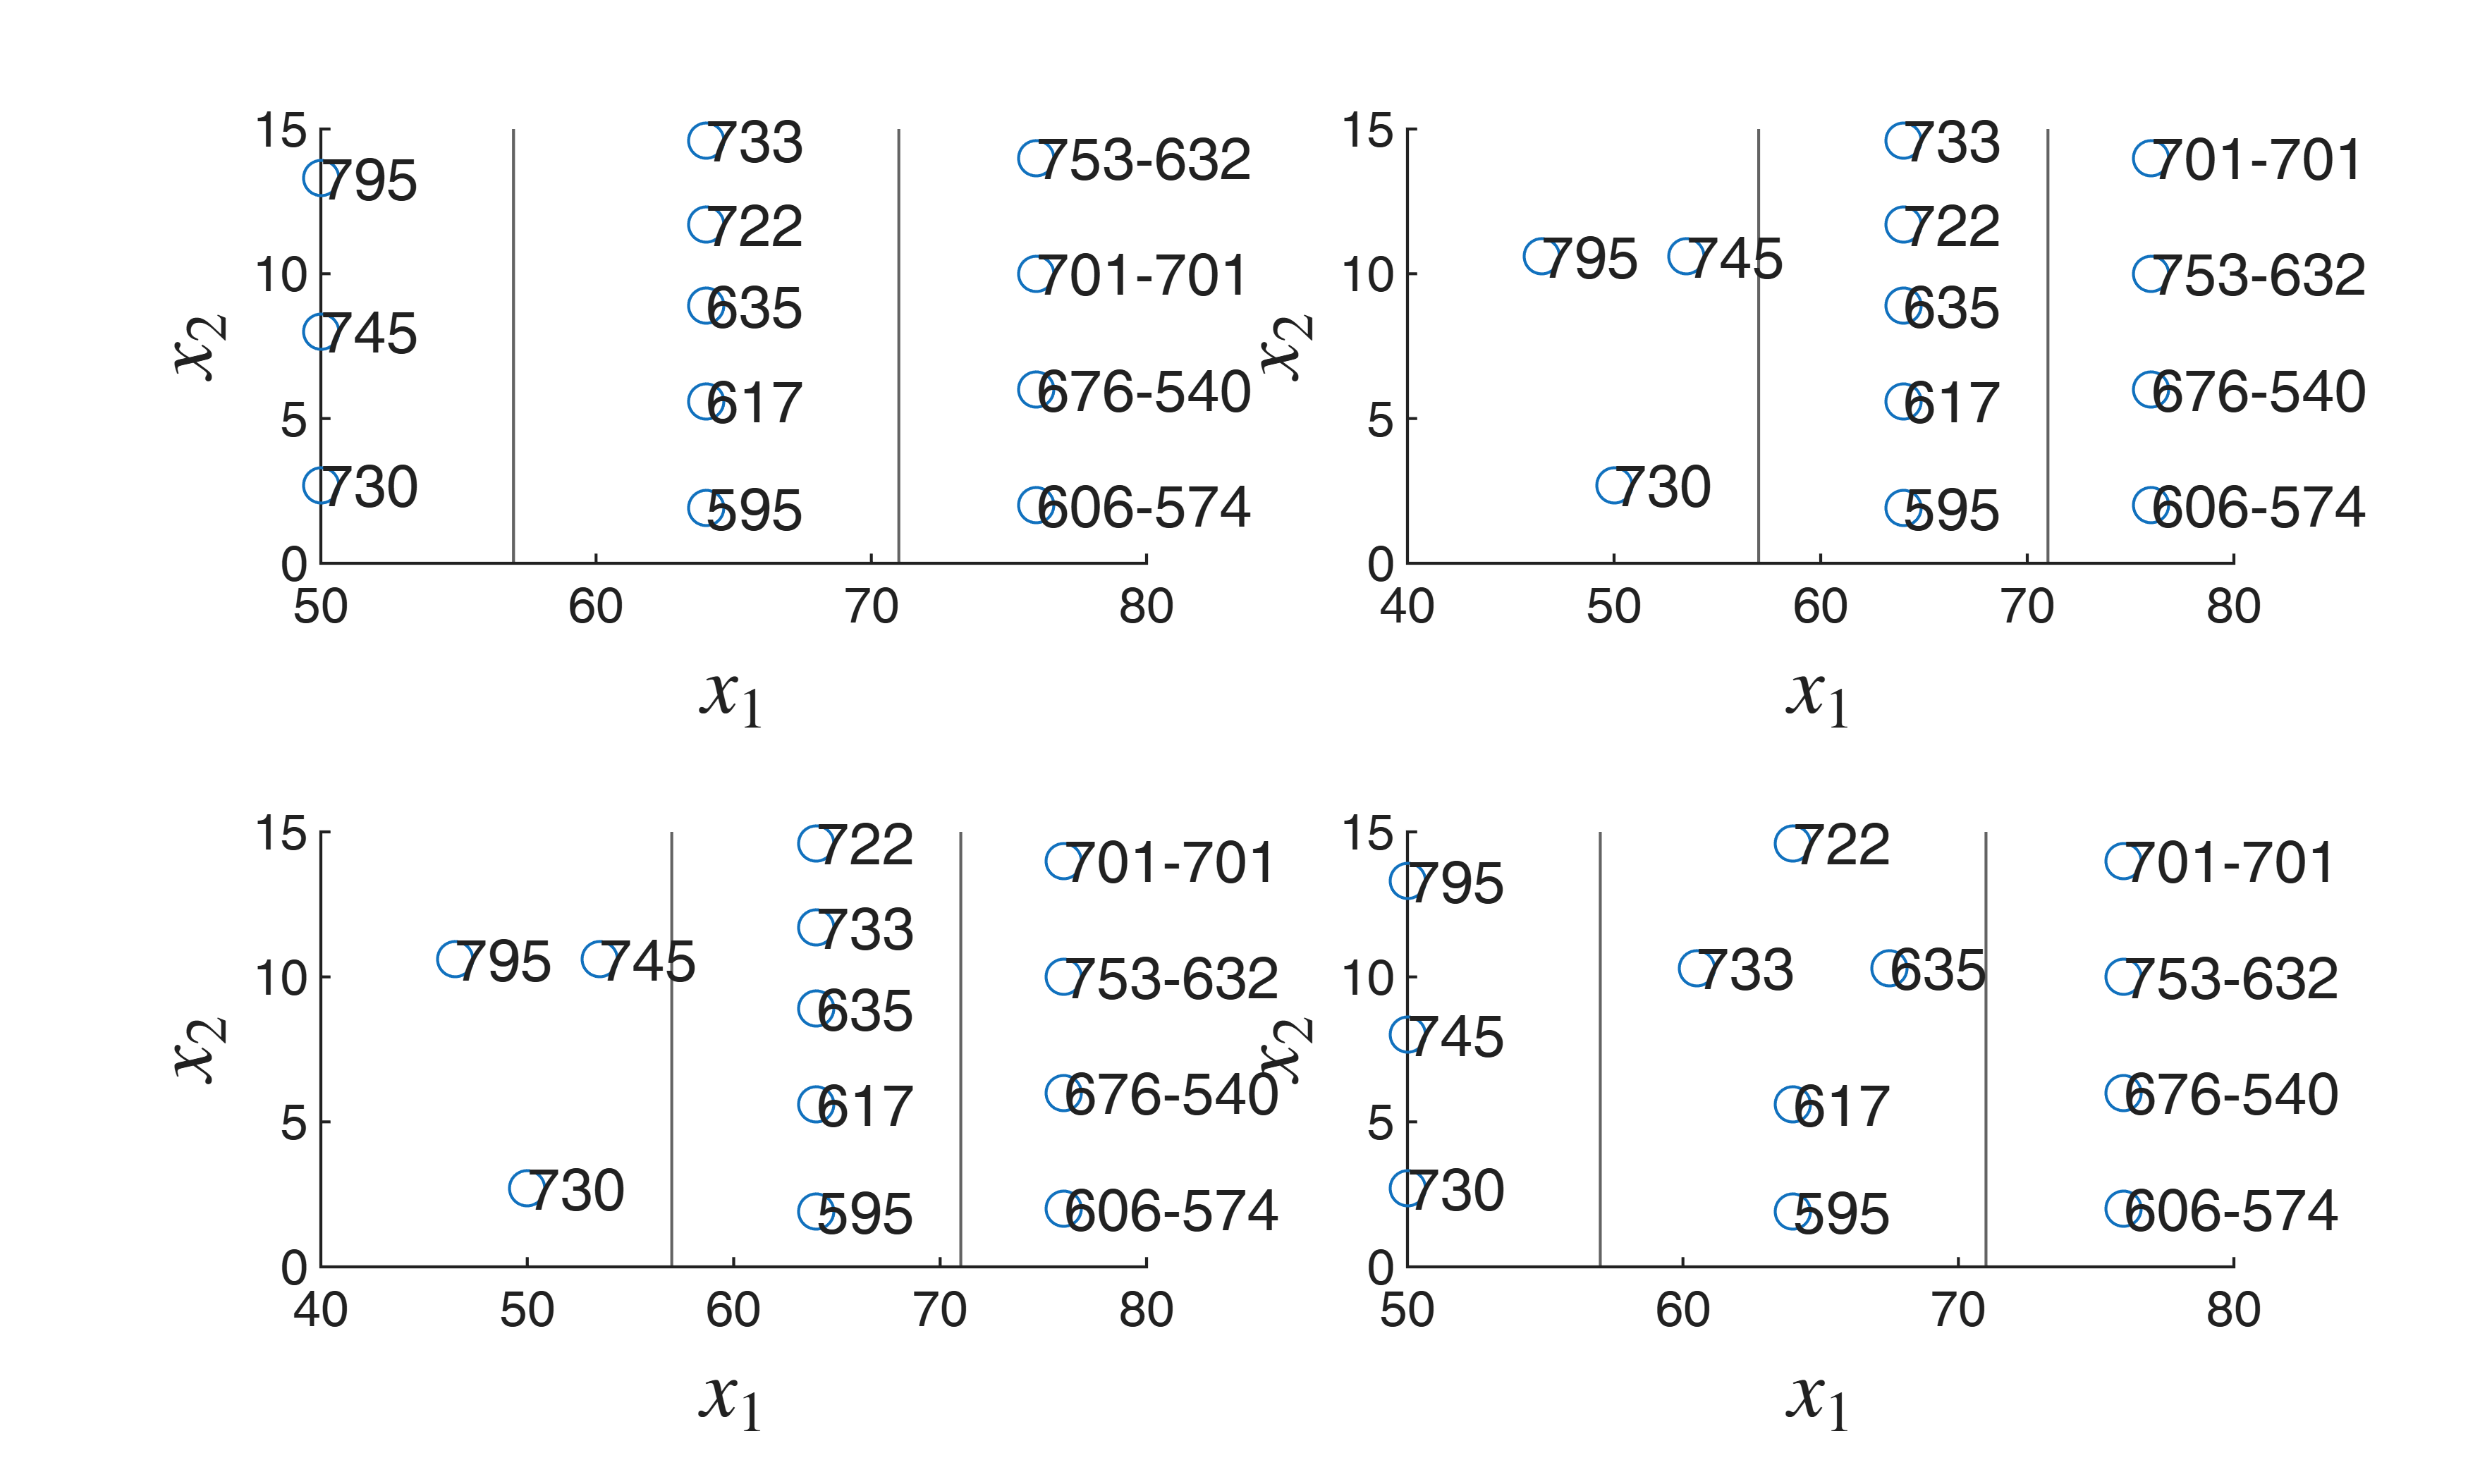

In [20]:
withtitle=false;
figure('Name', 'Figure 8: Configurations 3-6', 'NumberTitle', 'off');
position=3;
best=indsor(position);
Xbest=X1(:,:,best);
if withtitle==true
    title(['Configuration in position ' num2str(position)])
end
labXbest=[string(y(1:4))+"-"+string(y(5:8)); string(y(9:end))];
Xbestc=Xbest([1:4 9:end],:);
subplot(2,2,1)
scatter(Xbestc(:,1),Xbestc(:,2),'o')
text(Xbestc(:,1),Xbestc(:,2),labXbest);
xlabel("$x_1$","Interpreter","latex","FontSize",fs)
ylabel("$x_2$","Interpreter","latex","FontSize",fs)
xline([57 71])
if withtitle==true
    title(['Configuration in position ' num2str(position)])
end


position=4;
best=indsor(position);
Xbest=X1(:,:,best);
if withtitle==true
    title(['Configuration in position ' num2str(position)])
end
labXbest=[string(y(1:4))+"-"+string(y(5:8)); string(y(9:end))];
Xbestc=Xbest([1:4 9:end],:);
subplot(2,2,2)
scatter(Xbestc(:,1),Xbestc(:,2),'o')
text(Xbestc(:,1),Xbestc(:,2),labXbest);
xlabel("$x_1$","Interpreter","latex","FontSize",fs)
ylabel("$x_2$","Interpreter","latex","FontSize",fs)
xline([57 71])


position=5;
best=indsor(position);
Xbest=X1(:,:,best);
if withtitle==true
    title(['Configuration in position ' num2str(position)])
end
labXbest=[string(y(1:4))+"-"+string(y(5:8)); string(y(9:end))];
Xbestc=Xbest([1:4 9:end],:);
subplot(2,2,3)
scatter(Xbestc(:,1),Xbestc(:,2),'o')
text(Xbestc(:,1),Xbestc(:,2),labXbest);
xlabel("$x_1$","Interpreter","latex","FontSize",fs)
ylabel("$x_2$","Interpreter","latex","FontSize",fs)
xline([57 71])
if withtitle==true
    title(['Configuration in position ' num2str(position)])
end


position=6;
best=indsor(position);
Xbest=X1(:,:,best);


labXbest=[string(y(1:4))+"-"+string(y(5:8)); string(y(9:end))];
Xbestc=Xbest([1:4 9:end],:);
subplot(2,2,4)
scatter(Xbestc(:,1),Xbestc(:,2),'o')
text(Xbestc(:,1),Xbestc(:,2),labXbest);
xlabel("$x_1$","Interpreter","latex","FontSize",fs)
ylabel("$x_2$","Interpreter","latex","FontSize",fs)
xline([57 71])

In [21]:


if withtitle==true
    title(['Configuration in position ' num2str(position)])
end
if prin==1
    print -depsc conf3-6.eps
end


<a id="TMP_2584"></a>

## Figure 9: Weighted regression: outlier detection on the most plausible configuration

-------------------------
Signal detection loop
Signal is in final step of the search
-------------------
Signal validation exceedance of upper envelopes
Validated signal


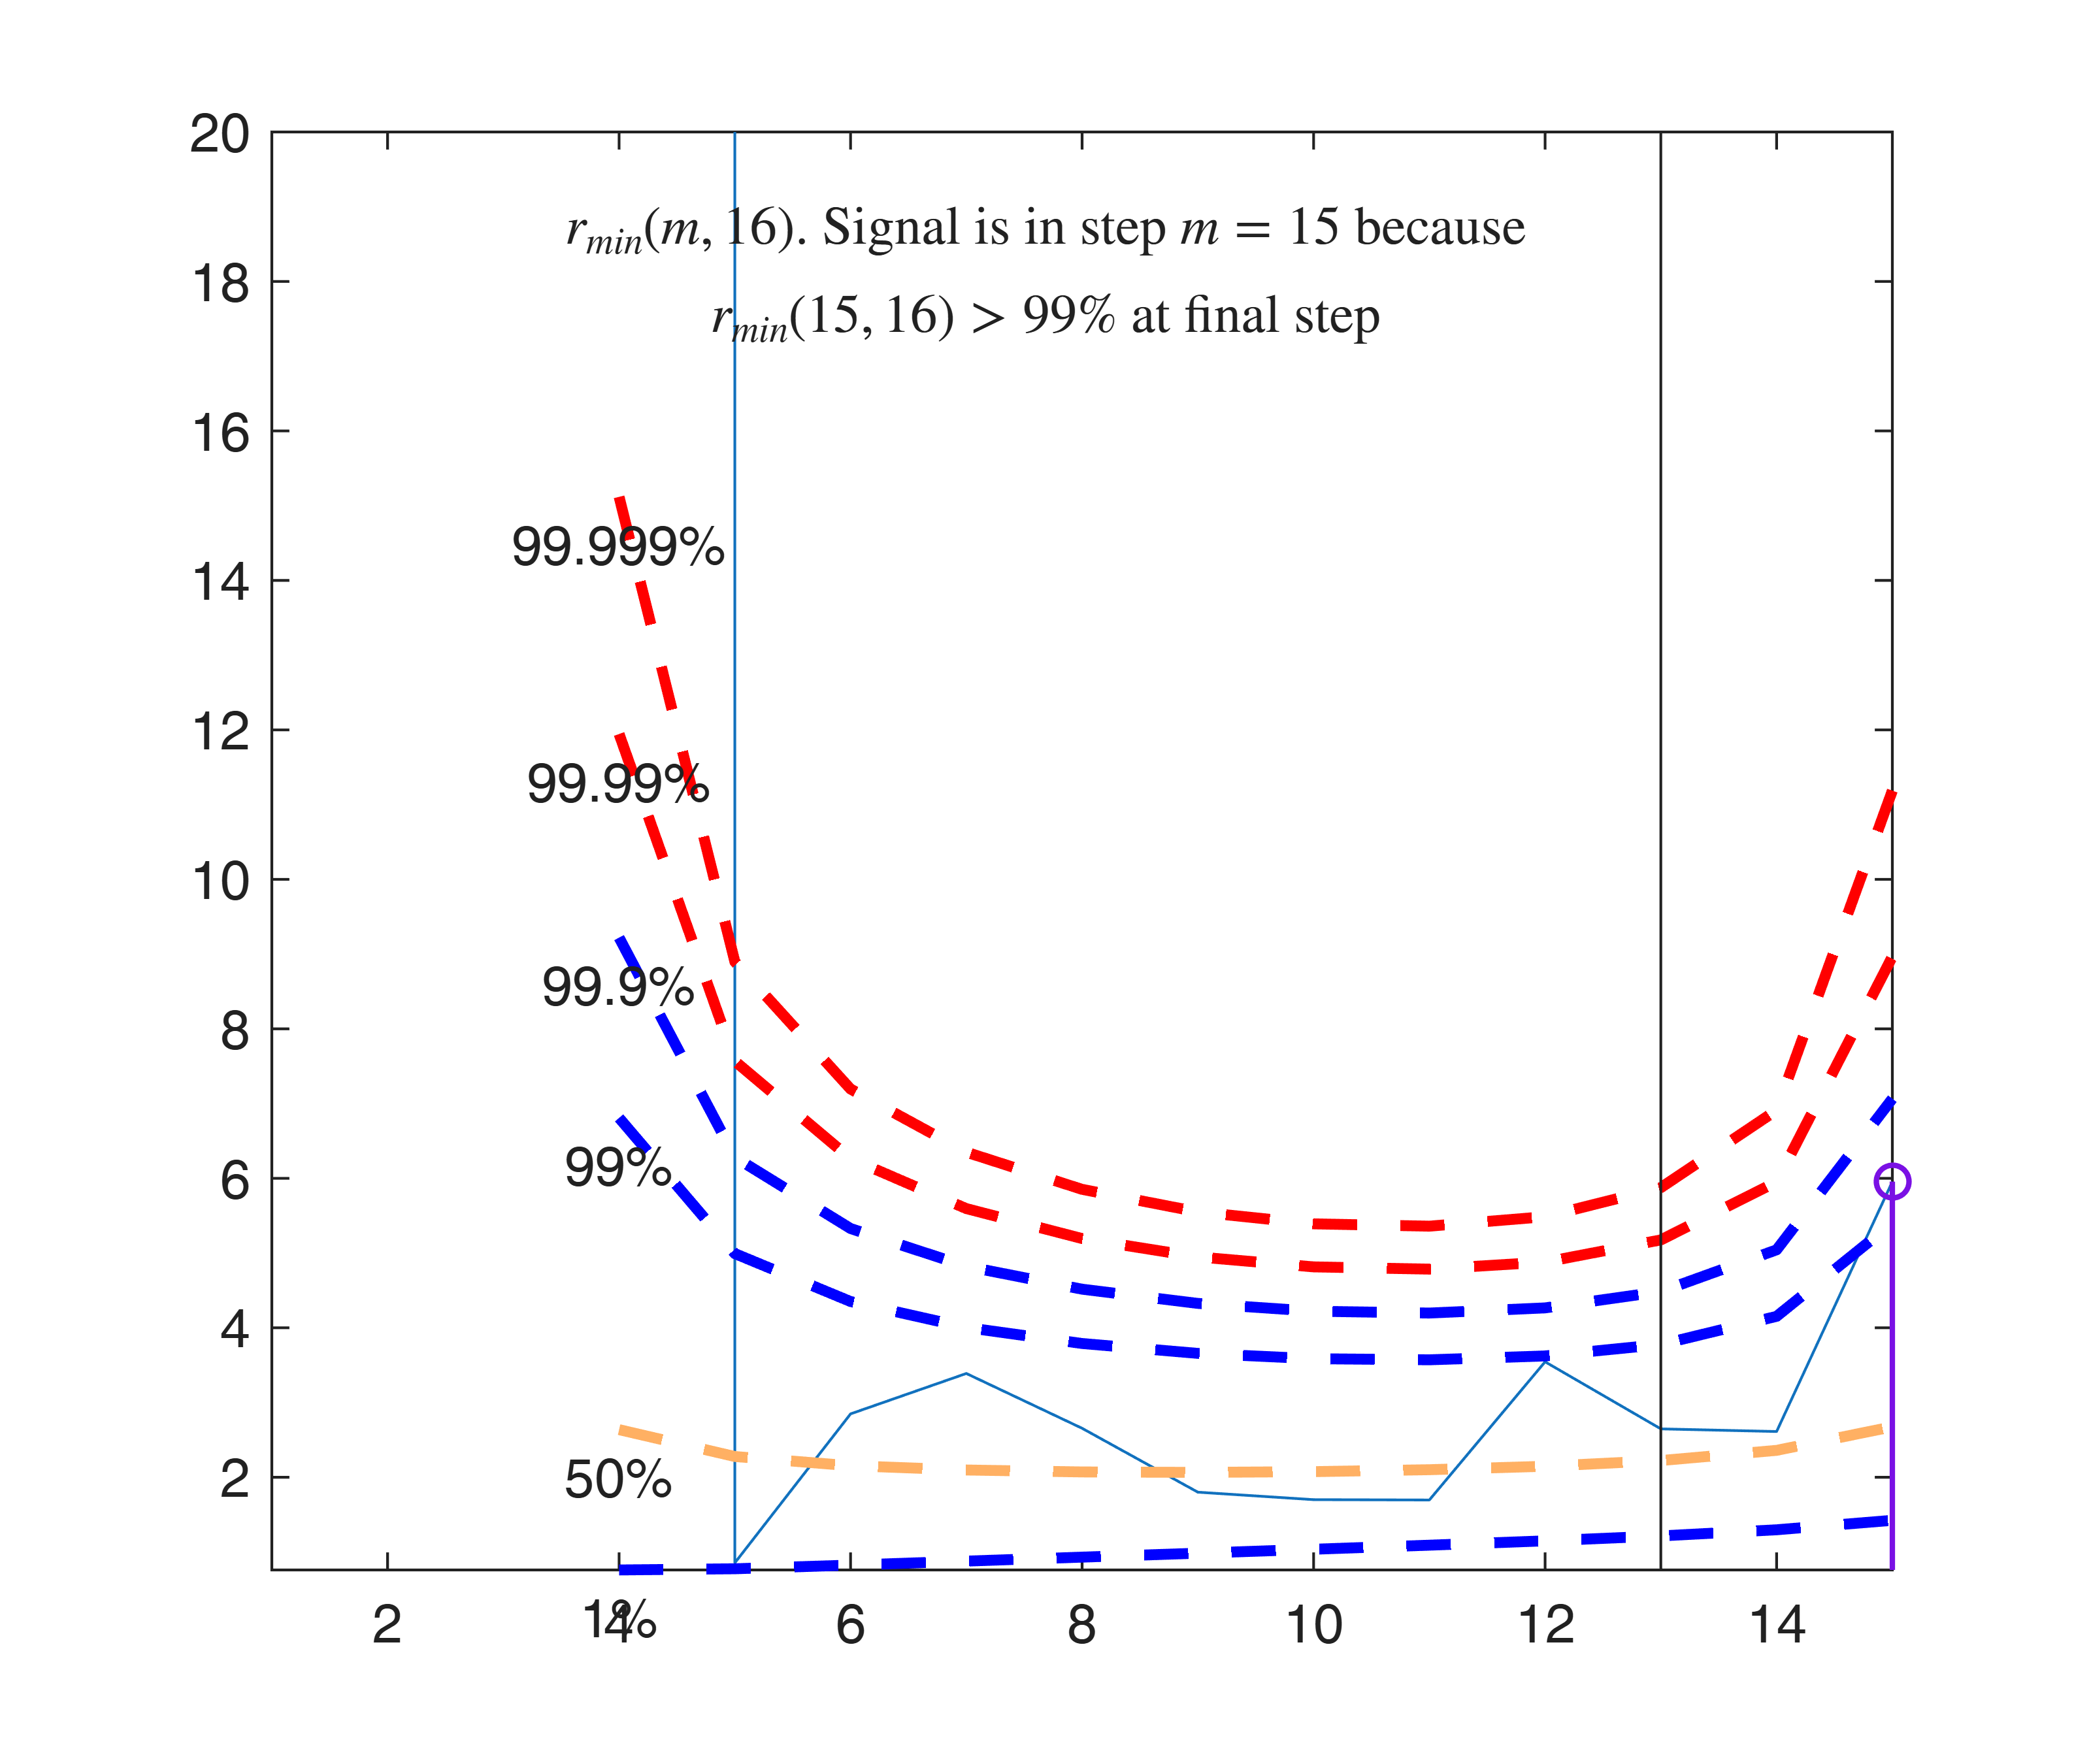

-------------------------------
Start resuperimposing envelopes from step m=14
Superimposition stopped because r_{min}(15,16)>99% envelope
$r_{min}(15,16)>99$\% envelope
----------------------------
Final output
Number of units declared as outliers=1
Summary of the exceedances
           1          99         999        9999       99999
           0           2           1           1           1


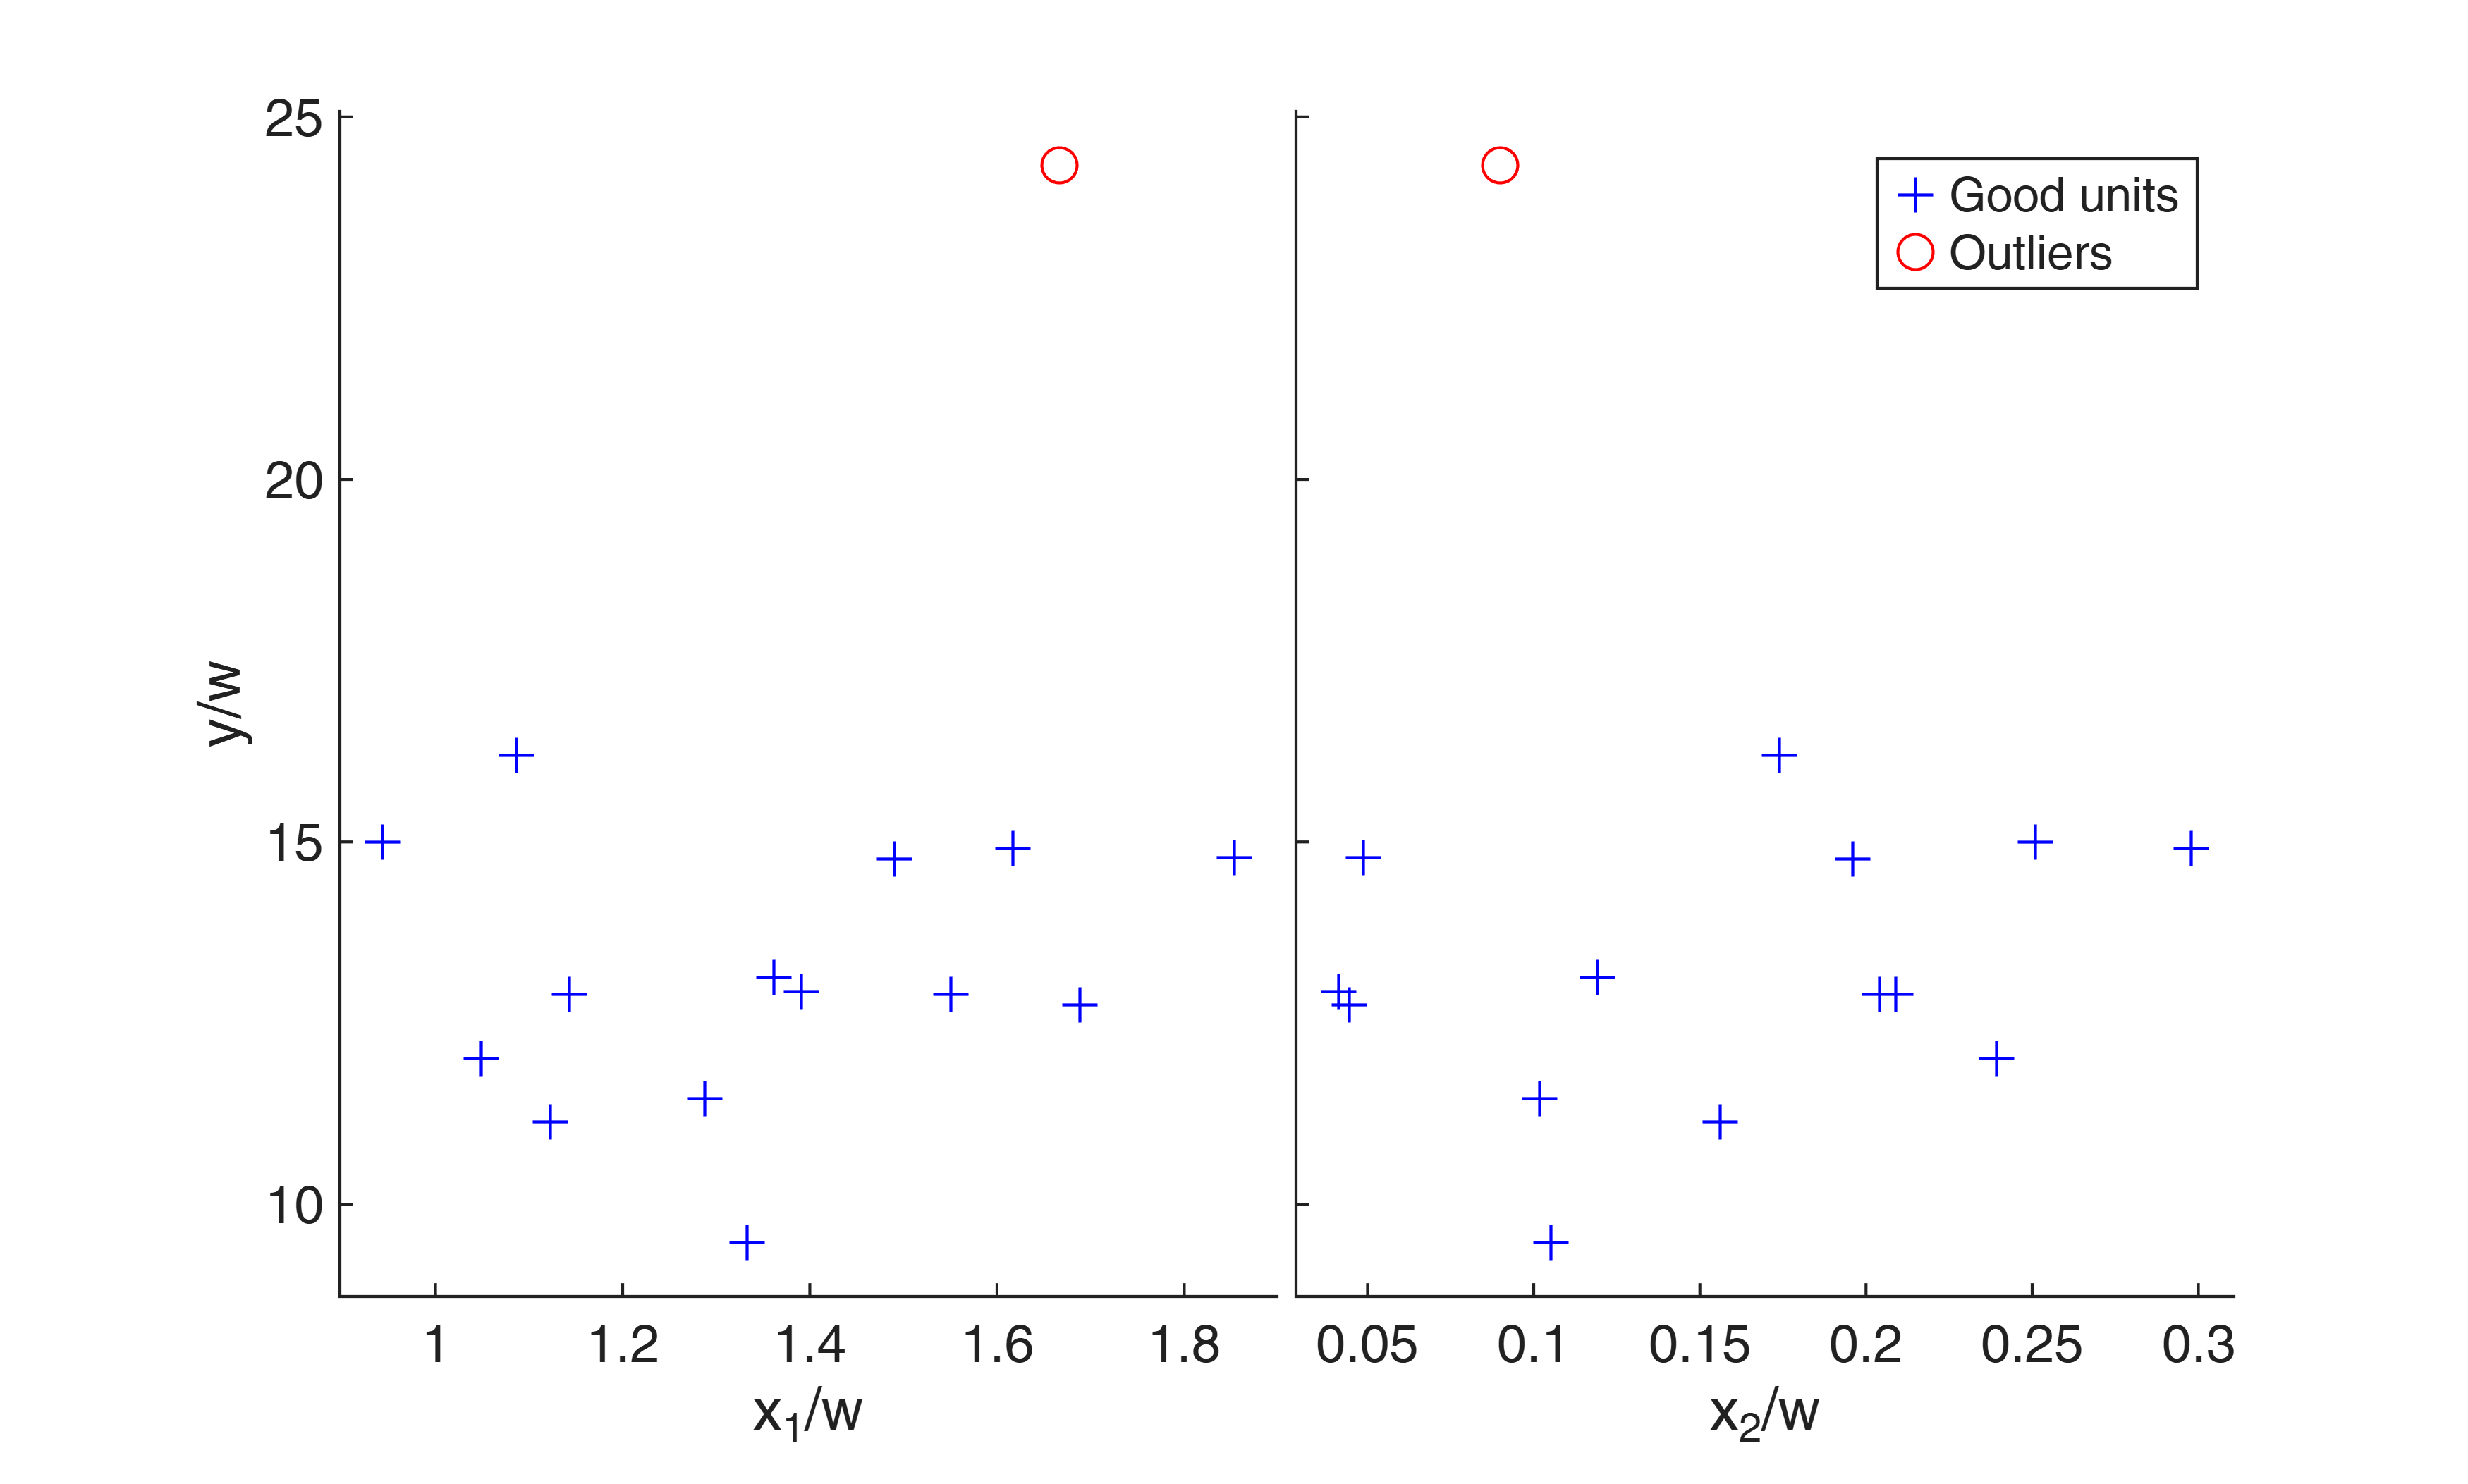

In [22]:
position=1;
best=indsor(position);
Xbest=X1(:,:,best);


yweighted=y./se;
Xweighted=Xbest./se;
outFSR=FSR(yweighted,Xweighted,'namey','y/w','nameX',["x_1/w" "x_2/w"]);

In [23]:


if prin==1
    print -depsc yXbest.eps
end


% Code below is just to show that using LXS we obtain the same result
%{
    % the rows below just to show that
    outLXS=LXS(yweighted,Xweighted);
    resindexplot(outLXS,'conflev',1-0.01/length(y),'numlab',{1})
%}


%% Alternative way of obtaining left panel of Figure 9 (used in the manuscript)
figure('Name', 'Figure 9 (left panel):','NumberTitle', 'off');
outLXS=LXS(yweighted,Xweighted,'nsamp',0);

Total estimated time to complete LMS:  0.00 seconds


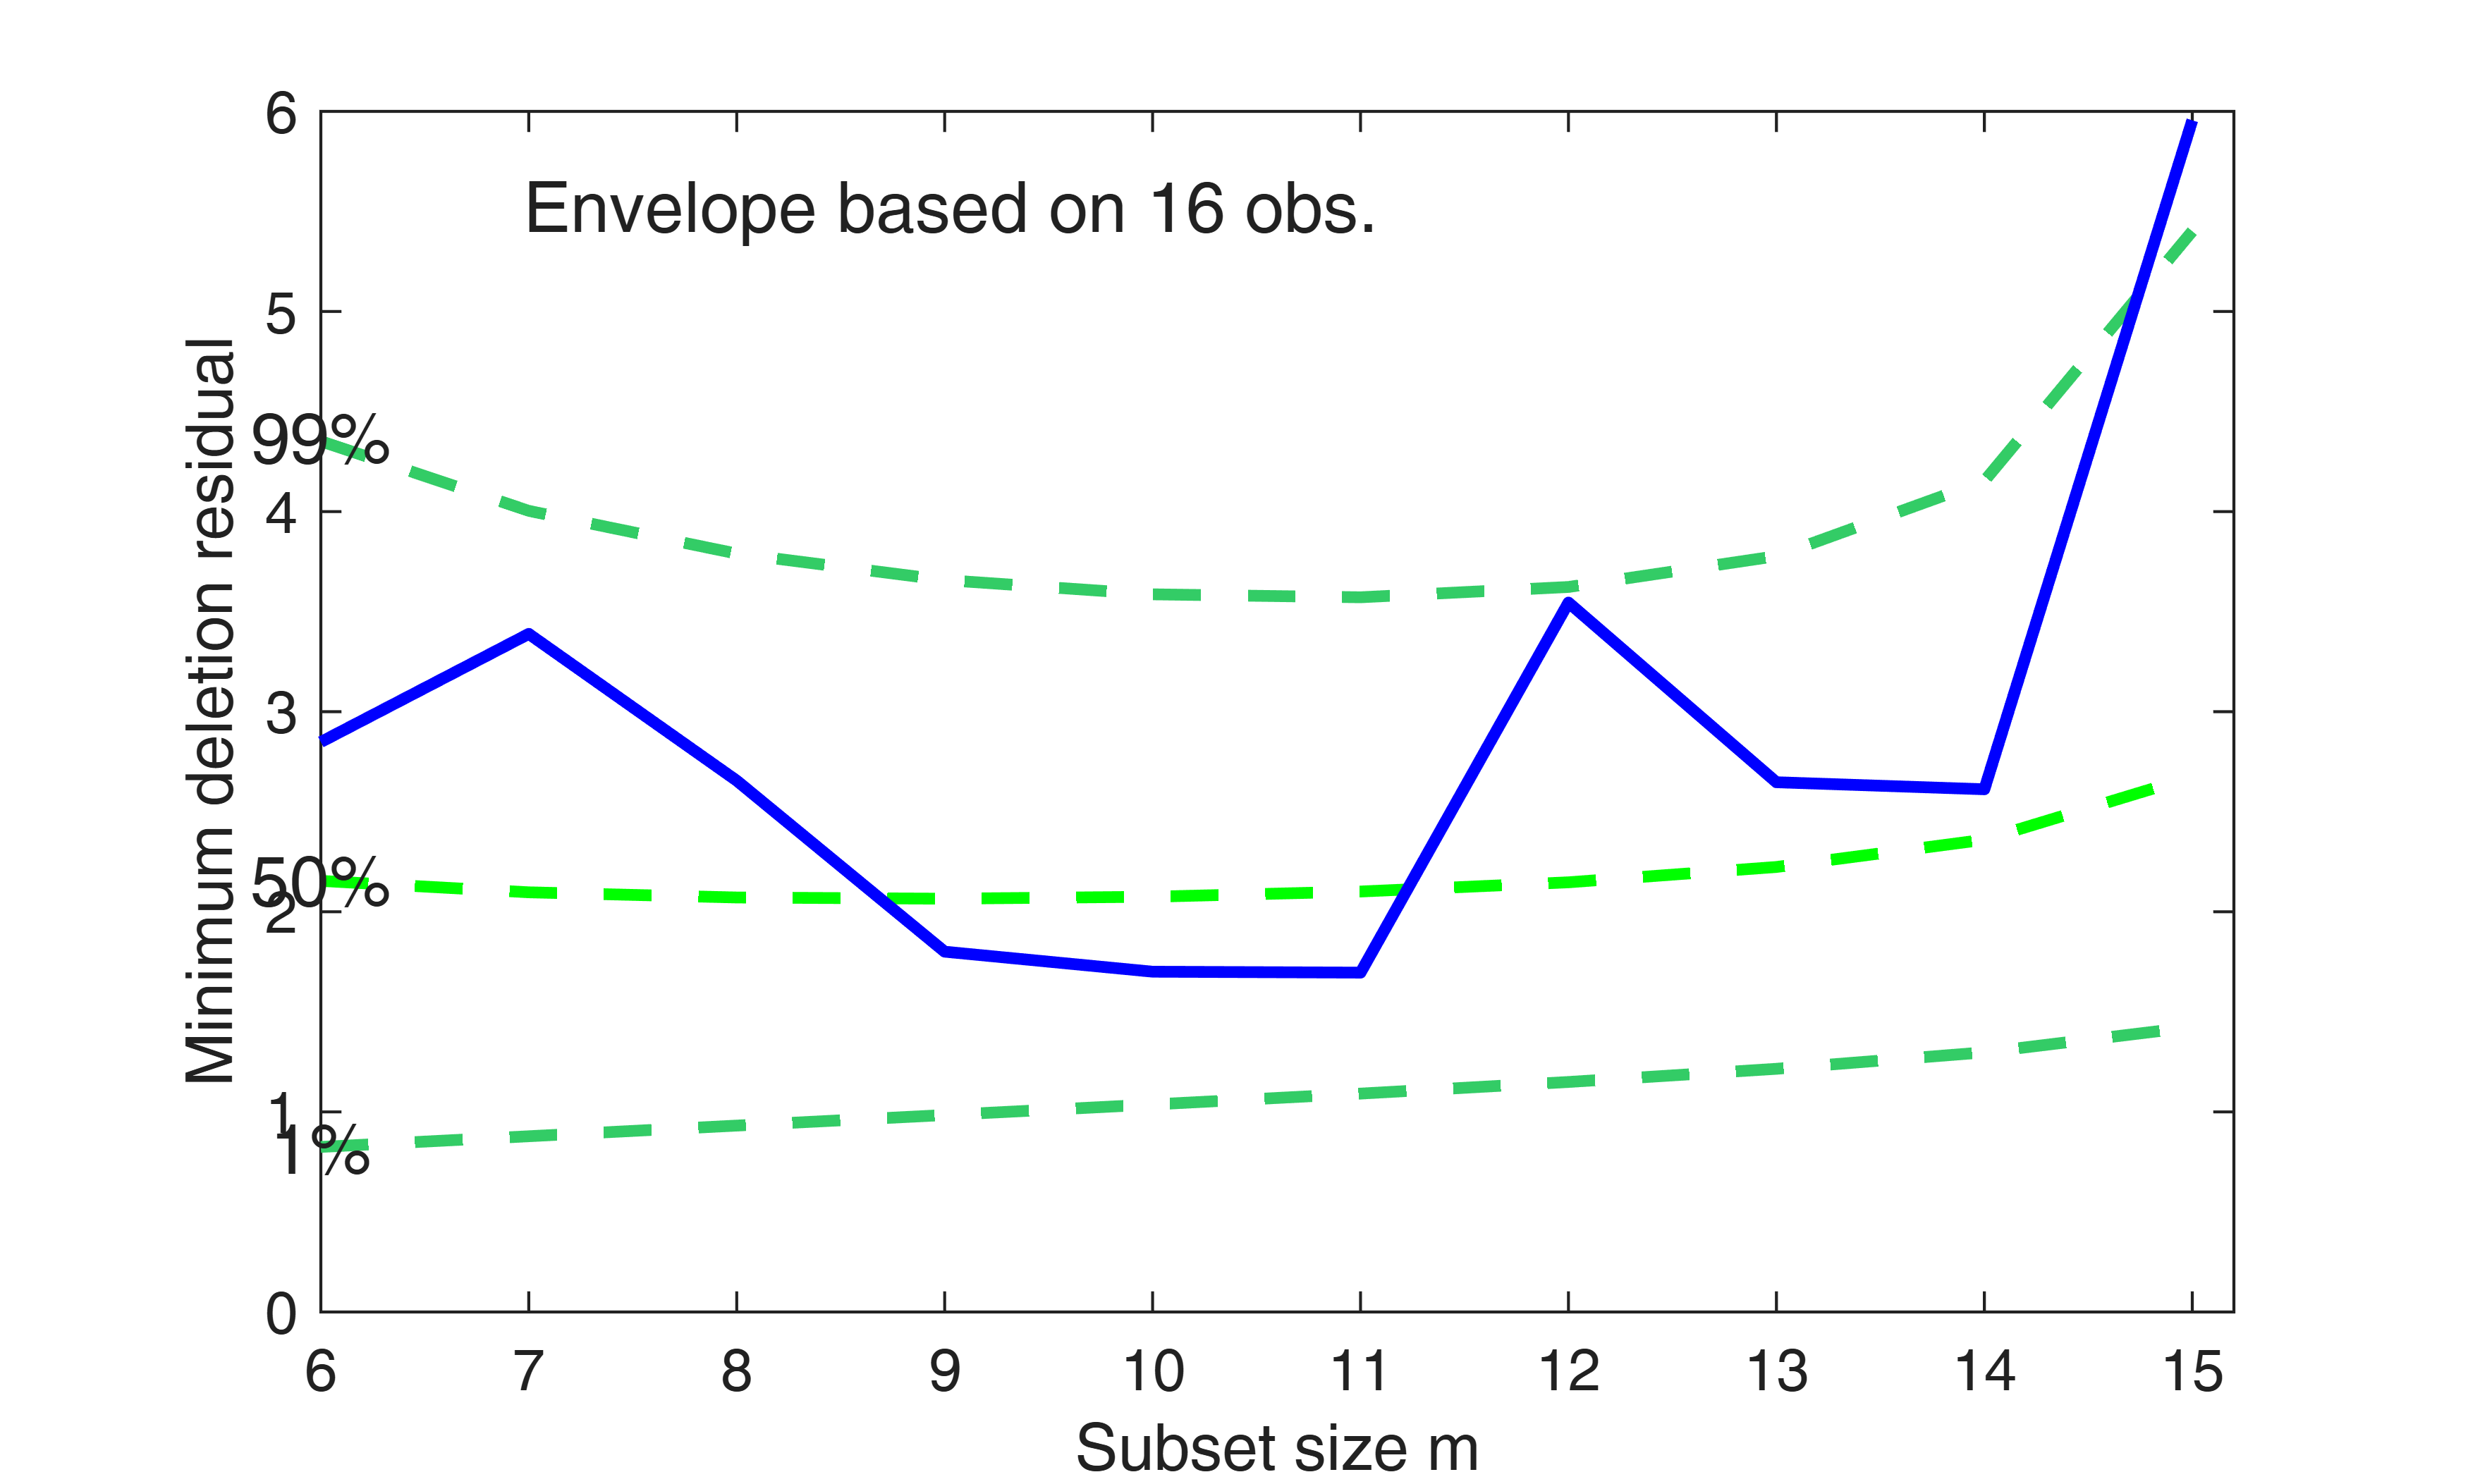

In [24]:
[out]=FSReda(yweighted,Xweighted,outLXS.bs,'init',6);


mdrplot(out,'lwdenv',2,'ylimy',[0 6],'xlimx',[6 15.2]');

In [25]:


if prin==1
    print -depsc mdrXbest.eps
end


<a id="TMP_1694"></a>

## Figure 10: HistFS plots

Results from analysis of 165,888 permutations: left\-hand panel values of right\-hand panel values of Histograms of distribution of the statistics with position of the selected 564 configurations in scarlet



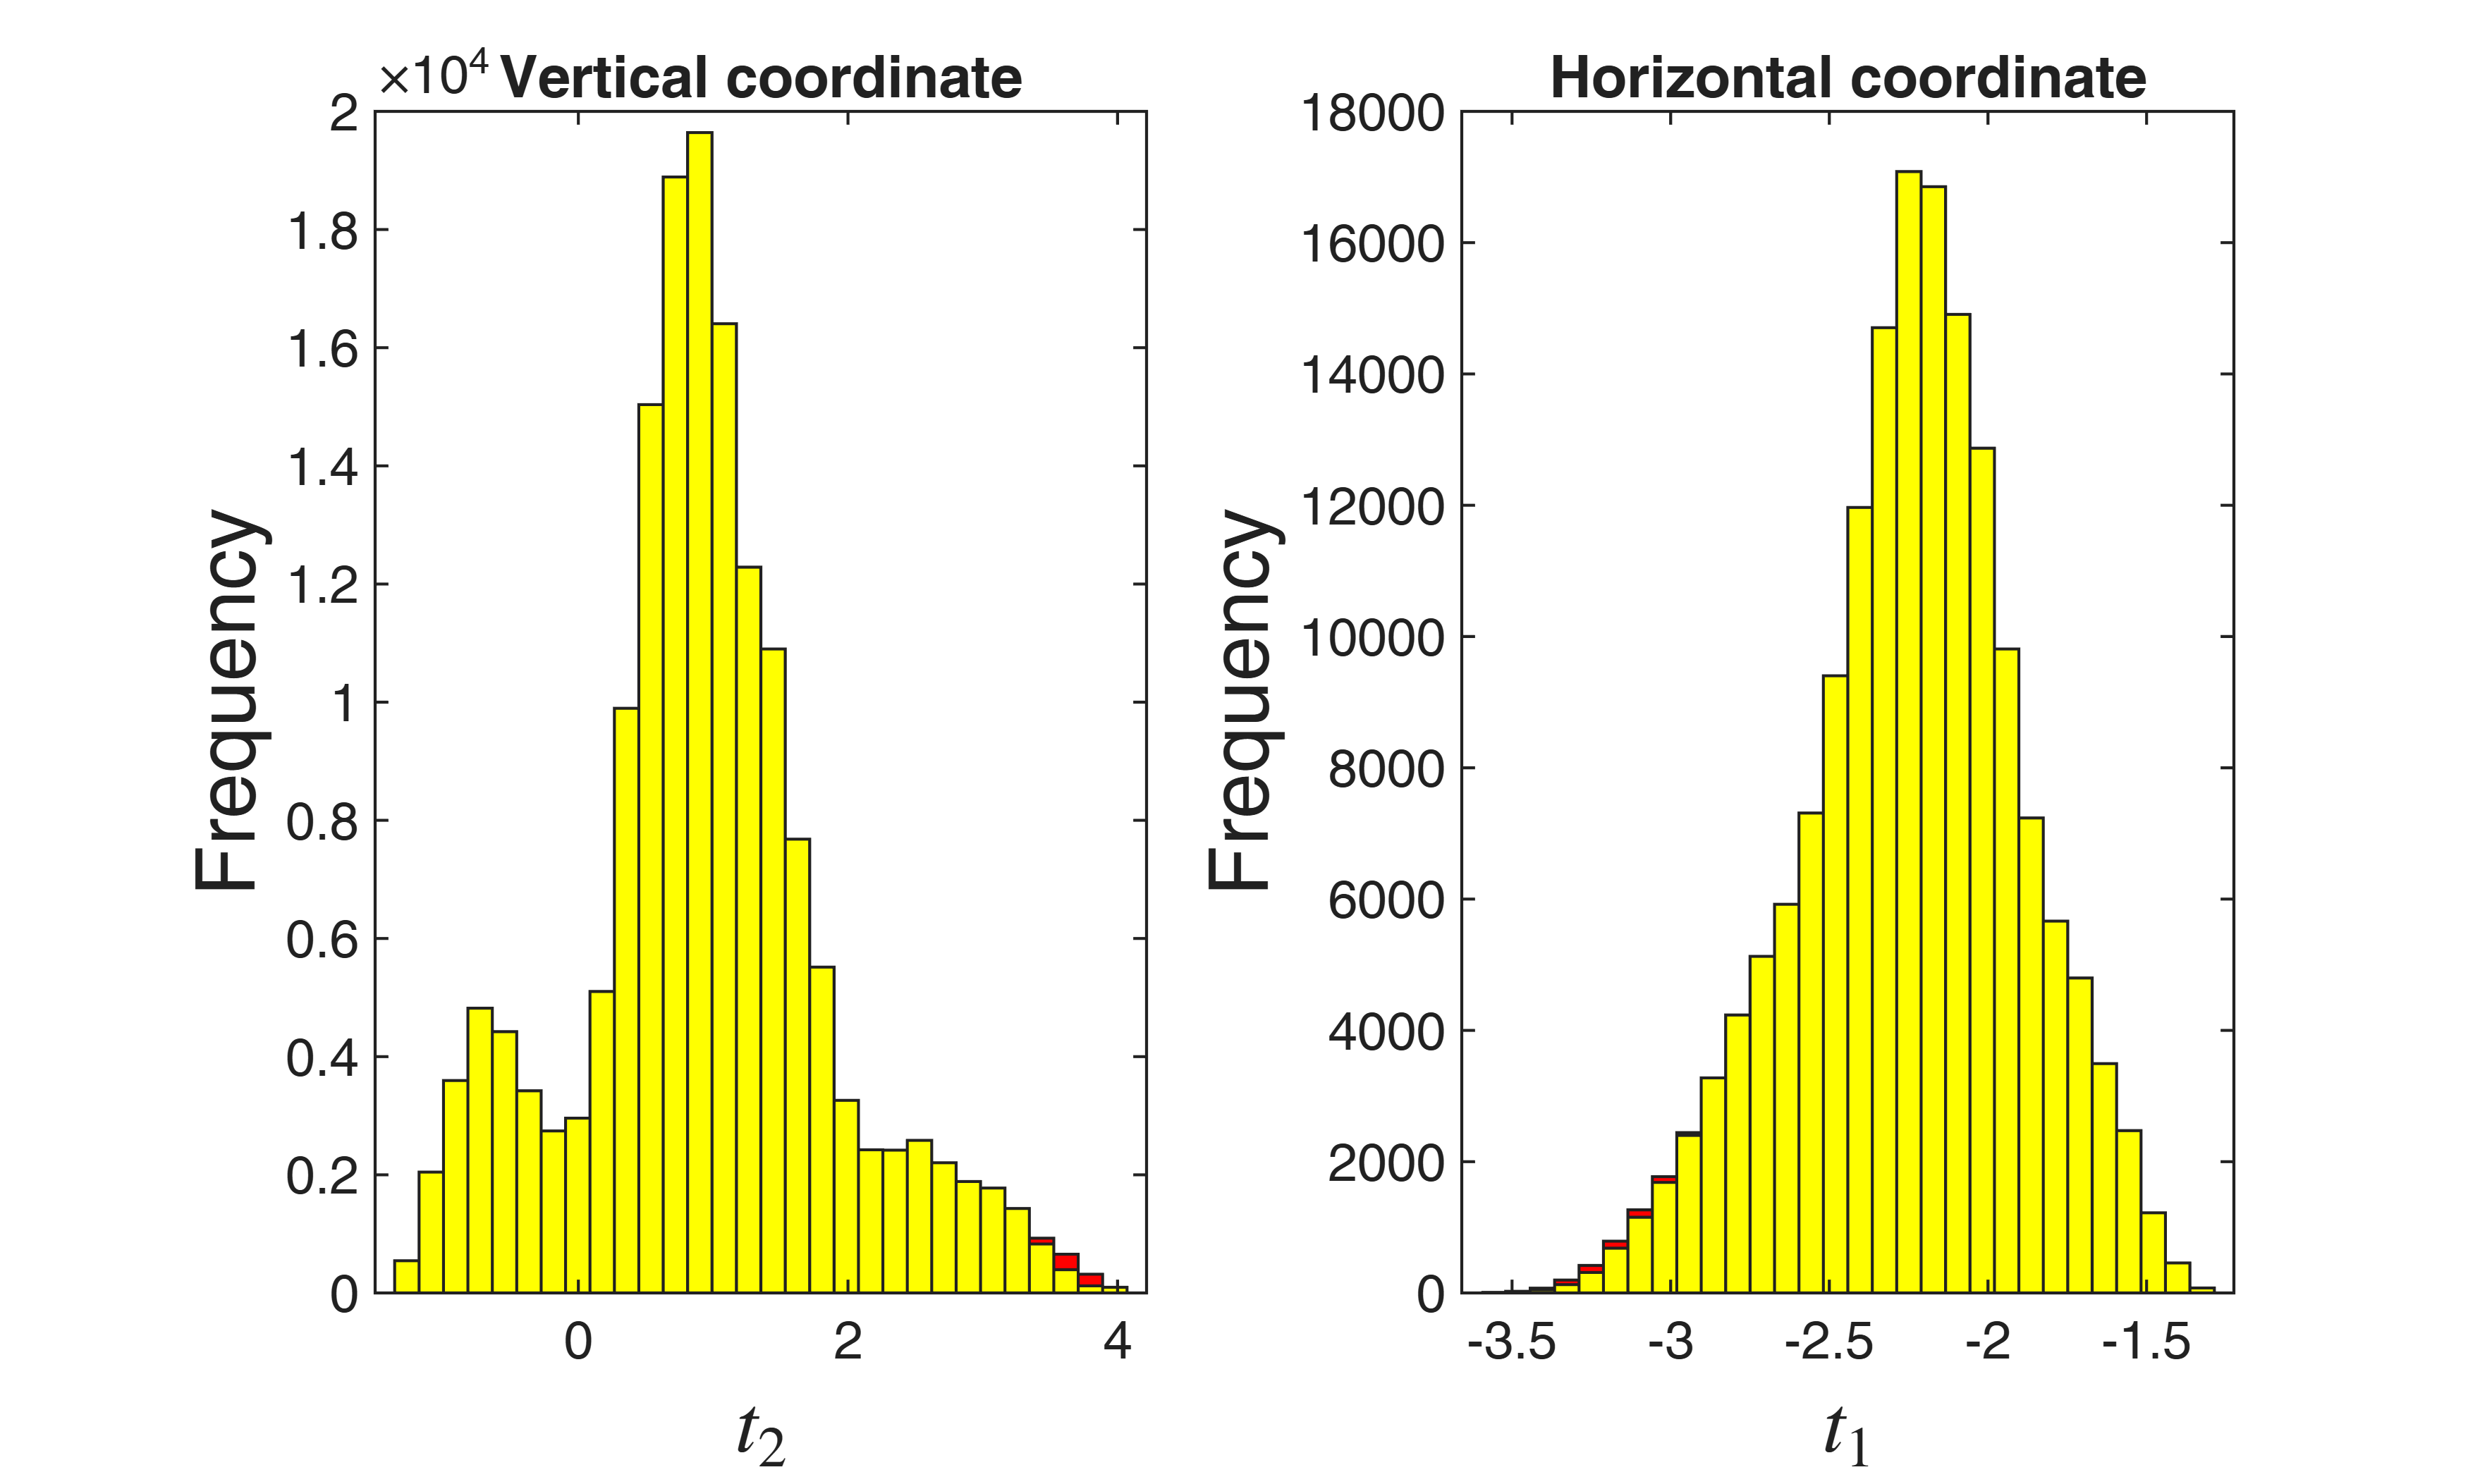

In [26]:
figure('Name', 'Figure 10: Histograms of distribution of the statistic with pos of best 564', 'NumberTitle', 'off');
nr=1;
nc=2;
yl=10000;
subplot(nr,nc,1)
histFS(TTstatreal(:,2),30,group,{ },gca,'yr');
ylabel("Frequency","FontSize",14)
title('Vertical coordinate')
xlabel("$t_2$","Interpreter","latex","FontSize",14)
subplot(nr,nc,2);
histFS(TTstatreal(:,1),30,group,{ },gca,'yr');
title('Horizontal coordinate');
xlabel("$t_1$","Interpreter","latex","FontSize",14)
ylabel("Frequency","FontSize",14)

In [27]:


if prin==1
    print -depsc histFS.eps
end


<a id="TMP_175e"></a>

## Section 10: find minimum and maximum dbp

min and max using the best configuration


In [28]:
outLM=fitlm(Xbest,y);
pred=predict(outLM);
MINdbp=min(pred);
MAXdbp=max(pred);
disp('Best configuration')

Best configuration

In [29]:
disp(['Minimum predicted value: ', sprintf('%d', round(MINdbp))]);

Minimum predicted value: 579

In [30]:
disp(['Maximum predicted value: ', sprintf('%d', round(MAXdbp))]);

Maximum predicted value: 788

In [31]:


% Calculate the maximum predicted value across all configurations
MAXdbpALL = max(FitMinMax(:,2));
disp(['Maximum predicted value across all configurations: ', sprintf('%d', round(MAXdbpALL))]);

Maximum predicted value across all configurations: 797


<a id="TMP_3284"></a>

## Section 10: number of t tests greater than 1.96 for horizontal and vertical

In [32]:
nsigtesth=sum(abs(TTstatreal(:,1))>1.96);
nsigtestv=sum(abs(TTstatreal(:,2))>1.96);
% Show these numbers in the Command Window
% Display the number of significant tests for horizontal and vertical effects
fprintf('Number of significant tests for horizontal effect: %d\n', nsigtesth);

Number of significant tests for horizontal effect: 133508

In [33]:
fprintf('Number of significant tests for vertical effect: %d\n', nsigtestv);

Number of significant tests for vertical effect: 18663